# Setting

This project provides a practical demonstration of black-box model extraction attacks against Machine Learning as a Service (MLaaS) prediction APIs. Using a credit card fraud detection scenario [1], the project illustrates how an adversary with no prior knowledge of a model's internal architecture, weights, or exact training data can reconstruct high-fidelity clones and surrogate models utilizing purely input-output queries.

# Victim Model Creation

To evaluate the security boundaries of Machine Learning as a Service (MLaaS) frameworks, this framework establishes two distinct victim black-box oracles: a mathematically interpretable Logistic Regression (LR) model and a non-linear, deep Multi-Layer Perceptron (MLP). Both models are evaluated against the threat models outlined in foundational model extraction literature [1], [3], [4]. Both models are trained on an institutionally relevant financial fraud dataset to simulate an operational deployment in a high-stakes corporate environment.

## Modules

In [1]:
# Standard Libraries
import pandas as pd
import numpy as np
import os

# Statistics libraries
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import joblib

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

The **Credit Card Fraud Detection Dataset 2023** (https://doi.org/10.34740/kaggle/dsv/6492730) contains anonymized credit card transaction records from European cardholders collected in 2023. It includes over 550,000 transactions. The dataset consists of features V1–V28, which are the principal components obtained via a Principal Component Analysis (PCA) transformation to protect user identities and reduce dimensionality, along with the transaction Amount and a binary fraud label (``Class``).

To evaluate model extraction under varying degrees of attacker knowledge, the dataset is partitioned into three isolated environments:
>Target API Training ($D$): 75% of the data ,where the victim models are trained on.

>Adversary Proxy ($D'$): 20% of the data,  acting as a massive pool of zero-leakage ($D \cap D' = \emptyset$), feature-aligned data.

>Evaluation ($D''$): 5% of the data. 

In [2]:
df_2023 = pd.read_csv("creditcard_2023.csv")

df_2023.drop('id', axis=1, inplace=True)
df_2023.dropna(inplace=True)
df_2023.drop_duplicates(inplace=True)

print(df_2023.head())

# Starified 75% for API Training (Target Model)
train_df, temp_df = train_test_split(df_2023, train_size=0.75, random_state=42, stratify=df_2023['Class'])

# Split the remaining 25% into Adversary base (80% of remainder) and Evaluation (20% of remainder)
# Stratify here so eval_df remains perfectly balanced (50/50) like the training set.
adv_base_df, eval_df = train_test_split(temp_df, train_size=0.80, random_state=42, stratify=temp_df['Class'])

# Artificially imbalance the Adversary Proxy to match the 2013 dataset (~0.17% fraud)
# This guarantees the adversary faces the exact same class imbalance hurdle, but with aligned PCA features.
safe_adv = adv_base_df[adv_base_df['Class'] == 0]
fraud_adv = adv_base_df[adv_base_df['Class'] == 1].sample(frac=0.0035, random_state=42)
adv_df = pd.concat([safe_adv, fraud_adv]).sample(frac=1, random_state=42).reset_index(drop=True)

train_df.to_csv("creditcard_2023_api_train.csv", index=False)
adv_df.to_csv("creditcard_2023_adversary_proxy.csv", index=False)
eval_df.to_csv("creditcard_2023_eval.csv", index=False)

print(f"Target Model Training Data (D): {len(train_df)} rows (Balanced)")
print(f"Adversary Proxy Data (D'): {len(adv_df)} rows (Imbalanced)")
print(f"Evaluation Holdout: {len(eval_df)} rows (Balanced)")

         V1        V2        V3        V4        V5        V6        V7  \
0 -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1  0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605  0.406466   
2 -0.260272 -0.949385  1.728538 -0.457986  0.074062  1.419481  0.743511   
3 -0.152152 -0.508959  1.746840 -1.090178  0.249486  1.143312  0.518269   
4 -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549  0.658849   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0 -0.130006  0.727159  0.637735  ... -0.110552  0.217606 -0.134794  0.165959   
1 -0.133118  0.347452  0.529808  ... -0.194936 -0.605761  0.079469 -0.577395   
2 -0.095576 -0.261297  0.690708  ... -0.005020  0.702906  0.945045 -1.154666   
3 -0.065130 -0.205698  0.575231  ... -0.146927 -0.038212 -0.214048 -1.893131   
4 -0.212660  1.049921  0.968046  ... -0.106984  0.729727 -0.161666  0.312561   

        V25       V26       V27       V28    Amount  Class  
0  0.12

## Data split

In [3]:
train_df, test_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['Class'])

## Significant Variables Search

In [4]:
# Initial feature list
features = [f"V{i}" for i in range(1, 29)] + ["Amount"]
target_feature_count = 6

while len(features) > target_feature_count:
    formula = "Class ~ " + " + ".join(features)
    
    model = smf.glm(formula=formula, data=train_df, family=sm.families.Binomial())
    result = model.fit()
    
    z_scores = result.tvalues.drop('Intercept')
    
    # Weakest feature -> lowest absolute Z-score
    weakest_feature = z_scores.abs().idxmin()
    weakest_z_score = z_scores[weakest_feature]
    
    print(f"Dropping '{weakest_feature}' (Z-score: {weakest_z_score:.2f})")
    
    features.remove(weakest_feature)

final_formula = "Class ~ " + " + ".join(features)
final_model = smf.glm(formula=final_formula, data=train_df, family=sm.families.Binomial())
final_result = final_model.fit()

print("\n Target reached! The model has converged to the elite 6 features.\n")
print(final_result.summary())

Dropping 'Amount' (Z-score: 0.04)
Dropping 'V13' (Z-score: 1.97)
Dropping 'V5' (Z-score: -1.78)
Dropping 'V19' (Z-score: -3.05)
Dropping 'V27' (Z-score: 7.77)
Dropping 'V20' (Z-score: 5.07)
Dropping 'V2' (Z-score: 6.01)
Dropping 'V21' (Z-score: 8.37)
Dropping 'V28' (Z-score: 9.50)
Dropping 'V26' (Z-score: -10.21)
Dropping 'V25' (Z-score: 10.01)
Dropping 'V24' (Z-score: -17.06)
Dropping 'V22' (Z-score: 20.99)
Dropping 'V6' (Z-score: -21.23)
Dropping 'V15' (Z-score: -19.19)
Dropping 'V23' (Z-score: -24.58)
Dropping 'V9' (Z-score: -27.22)
Dropping 'V16' (Z-score: -28.30)
Dropping 'V7' (Z-score: -40.82)
Dropping 'V1' (Z-score: -28.93)
Dropping 'V18' (Z-score: -36.03)
Dropping 'V3' (Z-score: -35.56)
Dropping 'V17' (Z-score: -47.53)

 Target reached! The model has converged to the elite 6 features.

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Class   No. Observations:               341176
Model:                            GLM


To reduce overfitting, due to the large amount of independent variables, 29 fraud prediction variables were shrinked down to the 6 most important ones. Z-scores were used as an importance measure, where high positive scores signaled fraud and high negative scores signaled safe transactions. A loop was necessary, because the variables competed with each other, so removing one changed the importance of the others each time the model was rebuilt. The script repeatedly trained a logistic regression model on all 568,630 transactions, until only the strongest predictors remained. In the end, the model kept the top fraud indicators (V4, V11) and top safety indicators (V14, V12, V10,V8), while still preserving about 98% of the original accuracy (compared to the original - although not shown here due to legibility- Pseudo $R^2$ —a measure of how well the logistic regression model explains the observed outcomes— had a negligible drop of just -0.0145, meaning that the model retained nearly all its predictive power while discarding 23 features

The variable space was also shrunk to clearly illustrate the mechanics of formal model extraction. More specifically To solve the equations for an LR model with $d$ features, the attacker needs exactly $d+1$ queries. By reducing the features to $d=6$, it will be demonstrated, that an attacker only needs 7 queries to completely steal the LR model! 

In [5]:
# For Logistic Regression (Reduced Features) 
columns_to_keep = ['V4', 'V11', 'V10', 'V14', 'V12', 'V8']

X_train = train_df[columns_to_keep]
y_train = train_df['Class']
X_test = test_df[columns_to_keep]
y_test = test_df['Class']

# For MLP (All Features) 
Xnn_train = train_df.drop('Class', axis=1)
ynn_train = train_df['Class']
Xnn_test = test_df.drop('Class', axis=1)
ynn_test = test_df['Class']

## Distribution of classes


--- Class Distribution ---
Fraudulent (1): 170,588 records (50.00%)
Non-Fraudulent (0): 170,588 records (50.00%)


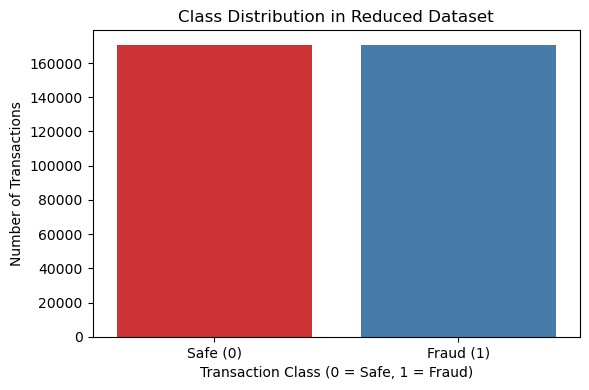

In [6]:
print("\n--- Class Distribution ---")
class_counts = train_df['Class'].value_counts()
class_percentages = train_df['Class'].value_counts(normalize=True) * 100

for cls, count in class_counts.items():
    label = "Fraudulent (1)" if cls == 1 else "Non-Fraudulent (0)"
    print(f"{label}: {count:,} records ({class_percentages[cls]:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=train_df, hue='Class', palette='Set1', legend=False)
plt.title('Class Distribution in Reduced Dataset')
plt.xlabel('Transaction Class (0 = Safe, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Safe (0)', 'Fraud (1)'])
plt.tight_layout()

As can be seen the dataset is very balanced. Real-world credit card fraud data is notoriously imbalanced, typically featuring less than 1% fraud. The only reason the dataset was not changed was to showcase how distribution imbalance of D and D' affect model extraction.

## Logistic Regression (LR)


Logistic Regression (LR) is a supervised machine learning algorithm used for binary classification problems. It predicts the probability, that a data point belongs to a particular class by applying the sigmoid function to a linear combination of input features.

The model is defined as:

$$
z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$

$$
P(y=1) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

where (w) represents the feature weights, (b) is the bias term, and (\sigma(z)) converts the output into a probability between 0 and 1.

In [7]:
# Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

print("Training the model...")

model.fit(X_train, y_train)

print("Training complete.\n")

results = {
    "feature_names": X_train.columns.tolist(),
    "weights": model.coef_[0],
    "bias": model.intercept_[0]
}

print("Model Bias:")
print(round(results["bias"], 4))

print("\nFeature Weights:")

for feature, weight in zip(results["feature_names"], results["weights"]):
    print(f"{feature}: {round(weight, 4)}")

Training the model...
Training complete.

Model Bias:
2.5439

Feature Weights:
V4: 2.8069
V11: 1.1071
V10: -1.2231
V14: -2.1755
V12: -1.8903
V8: -1.5066


In [8]:
# Save the trained model
joblib.dump(model, "logistic_model.pkl")

print("Model saved.")

Model saved.


## Multilayer Perceptron (MLP)


A Multilayer Perceptron (MLP) is a feedforward artificial neural network used for classification and regression tasks. It consists of an input layer, one or more hidden layers (2 here) and an output layer, where each neuron applies a weighted sum followed by a non-linear activation function (here ReLU (max(0,x))).

Mathematically, each layer computes:

$$
h^{(l)} = \sigma(W^{(l)} h^{(l-1)} + b^{(l)})
$$

where $W^{(l)}$ and $b^{(l)}$ are the weights and bias of layer (l) and $\sigma$ is a non-linear activation function.

The `Pipeline` ensures that preprocessing steps and the model are executed in a single, sequential workflow, preventing data leakage and simplifying training and evaluation. `StandardScaler` is used to normalize features by removing the mean and scaling to unit variance, which improves MLP performance by ensuring faster and more stable convergence during gradient-based optimization.

In [9]:
nn_pipeline = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', random_state=42, max_iter=1000)
)

nn_pipeline.fit(Xnn_train, ynn_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('mlpclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regul

In [10]:
# Save the trained model
joblib.dump(nn_pipeline, "nn_model.pkl")

print("Model saved.")

Model saved.


## Classification Capabilities

In [11]:
lr_preds = model.predict(X_test)
mlp_preds = nn_pipeline.predict(Xnn_test) 

print("\n" + "="*50)
print("  LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, lr_preds))

print("\n" + "="*50)
print("  NEURAL NETWORK (MLP) CLASSIFICATION REPORT")
print("="*50)
print(classification_report(ynn_test, mlp_preds))


  LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     42648
           1       0.98      0.94      0.96     42647

    accuracy                           0.96     85295
   macro avg       0.96      0.96      0.96     85295
weighted avg       0.96      0.96      0.96     85295


  NEURAL NETWORK (MLP) CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       1.00      1.00      1.00     42647

    accuracy                           1.00     85295
   macro avg       1.00      1.00      1.00     85295
weighted avg       1.00      1.00      1.00     85295



The LR and MLP models were deliberately selected to demonstrate distinct vulnerabilities in model extraction, directly supporting the threat models outlined in the literature.

The Logistic Regression model was chosen because its architecture, combined with an API, that exposes continuous probabilities, makes it perfectly susceptible to both formal equation-solving attacks [1] and predictive retraining attacks [4]. This dual vulnerability makes LR an ideal baseline to evaluate and compare the practical accuracy of learning-based approximation attacks against an exact mathematical extraction.

Conversely, the MLP Neural Network was selected and explicitly configured in our API simulation to return hard class labels only, omitting confidence scores. Hiding confidence scores is a standard MLaaS defensive heuristic discussed by Jagielski et al. [3]. While the piecewise linearity of ReLU networks normally allows for devastatingly precise cryptanalytic extraction, if floating-point outputs are available [2], restricting the API to hard labels effectively neutralizes exact equation-solving and critical-point attacks. This robust configuration forces an adversary to abandon exact mathematical weight extraction and rely entirely on less efficient, fidelity-limited proxy data retraining methods [3], [4], [6].

# Model Extraction using the Credit Card Fraud Detection (2013)

To evaluate the empirical boundaries of model extraction in an information-restricted environment, this phase establishes an adversarial framework using an independent public dataset. This simulates a zero-knowledge threat model ($D \cap D' = \emptyset$) where the adversary lacks access to the victim’s proprietary training data, institutional domain or preprocessing parameters [4].

The adversary assumes, that because both datasets share identical feature schemas (V1 through V28 and Amount), they are compatible.The attack pipeline executes two distinct strategies:

>A continuous-output parameter-stealing attack via direct mathematical extraction [1], [2].

>A hard-label functional approximation attack across variable query budgets using diverse local surrogate architectures [1], [3], [4], [6].

## Modules

In [12]:
# Standard Libraries
import numpy as np
import pandas as pd
import math
import joblib
import warnings

# Math & ML Libraries
from sklearn.model_selection import train_test_split
from scipy.special import logit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress sklearn warnings about feature names for cleaner output
warnings.filterwarnings('ignore')

## Load Dataset

The Credit Card Fraud Detection (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) contains credit card transactions made by European cardholders in September 2013, recorded over two days and is primarily used for fraud detection research. It is highly imbalanced, containing 284,807 transactions in total with only 492 labeled as fraud (0.172%), making it suitable for evaluating models under extreme class imbalance conditions.

The dataset consists mainly of anonymized numerical features (V1–V28) obtained through Principal Component Analysis (PCA), along with Time and Amount.

Using it, simulates a realistic attack environment where the adversary lacks access to the victim’s specific training domain or institutional dataset, relying instead on alternative, public proxy data to query the black-box target model [4], [6]. 

A sample of 250,000 records is established to act as the query pool.

In [13]:
proxy_df = pd.read_csv("creditcard.csv")

sample_size = 250000

proxy_df, _ = train_test_split(proxy_df, train_size=sample_size, stratify=proxy_df['Class'], random_state=42)

proxy_df = proxy_df.reset_index(drop=True)

print(proxy_df.head())

       Time        V1        V2        V3        V4        V5        V6  \
0  132511.0 -0.854943  1.074502  1.010323 -1.458924  0.481772  0.460360   
1  106241.0 -0.609430  0.902801  2.350858 -0.137193  0.081589 -0.234028   
2   88045.0  2.155044 -0.147191 -2.200839 -1.538507  0.260083 -2.080166   
3   44791.0 -2.014166  2.057500  0.800515 -0.046729  0.237468  1.924049   
4   21870.0  0.766471 -1.745360  0.790151 -0.543997 -1.368236  0.904343   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.451929  0.020700  0.858615  ... -0.251048 -0.376672 -0.076080  0.205251   
1  0.559418 -0.295972  1.579671  ... -0.291184 -0.410616 -0.301696 -0.116122   
2  0.788316 -0.712967  0.946952  ...  0.134024  0.643227 -0.044200  0.081633   
3 -1.105882 -3.077766 -0.190878  ... -0.813233 -0.423911 -0.088260 -1.321815   
4 -1.265998  0.254685  0.954710  ...  0.477607  0.903600 -0.409955 -0.851191   

        V25       V26       V27       V28  Amount  Class  
0 -0.0477

## Distribution of classes


--- Class Distribution ---
Non-Fraudulent (0): 249,568 records (99.83%)
Fraudulent (1): 432 records (0.17%)


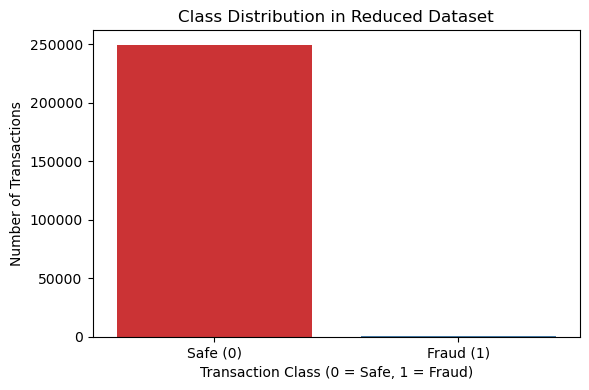

In [14]:
print("\n--- Class Distribution ---")
class_counts = proxy_df['Class'].value_counts()
class_percentages = proxy_df['Class'].value_counts(normalize=True) * 100

for cls, count in class_counts.items():
    label = "Fraudulent (1)" if cls == 1 else "Non-Fraudulent (0)"
    print(f"{label}: {count:,} records ({class_percentages[cls]:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=proxy_df, hue='Class', palette='Set1', legend=False)
plt.title('Class Distribution in Reduced Dataset')
plt.xlabel('Transaction Class (0 = Safe, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Safe (0)', 'Fraud (1)'])
plt.tight_layout()

As illustrated above, this real-world proxy dataset is heavily imbalanced, containing 249,568 safe transactions and only 432 labeled as fraud. This extreme skew ($D'$ distribution) will severely test the sample efficiency of the attacker's extraction methods.

## Feature Preprocessing & Scaling

To prepare the queries, the attacker fits an independent ``StandardScaler`` to the raw proxy features. This configuration ensures, that the attacker's preprocessing parameters are isolated from the target oracle's internal pipeline, maintaining the strict black-box assumption.

In [15]:
api_expected_features = [f"V{i}" for i in range(1, 29)] + ["Amount"]

X_proxy_raw = proxy_df[api_expected_features]

attacker_scaler = StandardScaler()
X_proxy_attacker_scaled_np = attacker_scaler.fit_transform(X_proxy_raw)

joblib.dump(attacker_scaler, "attacker_scaler.pkl")

X_proxy_scaled = pd.DataFrame(X_proxy_attacker_scaled_np, columns=api_expected_features)

## Formal Extraction Attack on Logistic Regression

In [16]:
lr_api = joblib.load("logistic_model.pkl")
lr_features = ['V4', 'V11', 'V10', 'V14', 'V12', 'V8']
d = len(lr_features)

X_queries = np.vstack([np.zeros(d), np.eye(d)])
X_queries_df = pd.DataFrame(X_queries, columns=lr_features)

api_probabilities = lr_api.predict_proba(X_queries_df)[:, 1]

y_logits = logit(api_probabilities)

X_augmented = np.hstack([np.ones((d + 1, 1)), X_queries])
extracted_params = np.linalg.solve(X_augmented, y_logits)

extracted_bias = extracted_params[0]
extracted_weights = extracted_params[1:]

exact_extracted_lr = LogisticRegression()

exact_extracted_lr.fit(np.zeros((2, d)), [0, 1]) 
exact_extracted_lr.coef_ = np.array([extracted_weights])
exact_extracted_lr.intercept_ = np.array([extracted_bias])

joblib.dump(exact_extracted_lr, "extracted_exact_lr.pkl")

print("Model saved.")

Model saved.


For the linear Logistic Regression API, an exact mathematical parameter extraction is implemented using an equation-solving methodology derived from Tramèr et al. [1]. Because the victim model relies on continuous probabilities, the adversary can apply the logit function (the inverse of the sigmoid) to the API's output to reveal the underlying linear equation: $\text{logit}(P) = W \cdot X + b$.

Because the victim model's feature space was reduced to $d = 6$ dimensions during training, the adversary requires exactly $d + 1$ (7) queries to solve the system of linear equations. By querying an array of zeros and an identity matrix, the attacker mathematically isolates the bias and each feature weight.

## Hardened API Defense


When the target API is hardened to return only discrete, hard labels (0 or 1) rather than continuous probabilities, the mathematical equation-solving attack is immediately neutralized. To extract the deep Multi-Layer Perceptron (MLP) target, the adversary is forced to abandon exact parameter recovery and rely on a learning-based functional approximation strategy [1], [3], [4].

However, the zero-knowledge proxy dataset introduces a massive hurdle: severe class imbalance (99.83% legitimate). The attacker knows that if a naive surrogate model is trained on any imbalanced data, it will predictably collapse—simply learning to output the majority class (here it is 0) to minimize its loss function, failing entirely to map the victim's complex decision boundary.

To solve this without burning a massive budget (although just for coverage purposes is done) on additional API queries, the attacker introduces a strategic optimization. Two training paradigms are evaluated side-by-side:

>Imbalanced (The Naive Baseline): The surrogate trains directly on the skewed data distribution to establish a baseline of failure.

>Balanced (The Optimized Attack): The attacker actively intervenes to help the surrogate learn. By applying algorithmic balancing (via class_weight='balanced'), the attacker artificially inflates the statistical importance of the rare fraud queries. This heavily penalizes the surrogate for misclassifying minority cases, purposefully forcing the architecture to stretch and adapt its geometry to enclose the target API's hidden logic.

A set of query budgets ranging from 1,000 to 100,000 instances is defined to measure how well this optimization improves sample efficiency across five distinct surrogate architectures.

In [17]:
query_budgets = [1000, 5000, 10000, 20000, 50000, 100000]

In [18]:
for budget in query_budgets:
    X_attack_lr_raw = X_proxy_raw[lr_features].iloc[:budget]
    y_api_labels_lr = lr_api.predict(X_attack_lr_raw)
    
    # Imbalanced
    surrogate_lr_imb = LogisticRegression(max_iter=1000, random_state=42)
    surrogate_lr_imb.fit(X_attack_lr_raw, y_api_labels_lr)
    joblib.dump(surrogate_lr_imb, f"surrogate_proxy_lr_{budget}_imbalanced.pkl")
    
    # Balanced
    surrogate_lr_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    surrogate_lr_bal.fit(X_attack_lr_raw, y_api_labels_lr)
    joblib.dump(surrogate_lr_bal, f"surrogate_proxy_lr_{budget}_balanced.pkl")

print("LR API Surrogate Models saved.")

LR API Surrogate Models saved.


## Extending the Attack to Neural Networks (MLP)

In [19]:
mlp_api = joblib.load("nn_model.pkl")

In [20]:
for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)
    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]

    # Imbalanced
    surrogate_mlp_lr_imb = LogisticRegression(max_iter=1000, random_state=42)
    surrogate_mlp_lr_imb.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_lr_imb, f"surrogate_proxy_mlp_lr_{budget}_imbalanced.pkl")
    
    # Balanced
    surrogate_mlp_lr_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    surrogate_mlp_lr_bal.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_lr_bal, f"surrogate_proxy_mlp_lr_{budget}_balanced.pkl")

print("MLP->LR Models saved.")

MLP->LR Models saved.


In [21]:
for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)
    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]
    
    # Imbalanced
    surrogate_rf_imb = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    surrogate_rf_imb.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_rf_imb, f"surrogate_proxy_mlp_rf_{budget}_imbalanced.pkl")

    # Balanced
    surrogate_rf_bal = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
    surrogate_rf_bal.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_rf_bal, f"surrogate_proxy_mlp_rf_{budget}_balanced.pkl")

print("MLP->RF Models saved.")

MLP->RF Models saved.


In [22]:
for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)
    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]

    # Imbalanced
    surrogate_mlp_svm_imb = LinearSVC(random_state=42, dual=False)
    surrogate_mlp_svm_imb.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_svm_imb, f"surrogate_proxy_mlp_svm_{budget}_imbalanced.pkl")

    # Balanced
    surrogate_mlp_svm_bal = LinearSVC(random_state=42, dual=False, class_weight='balanced')
    surrogate_mlp_svm_bal.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_svm_bal, f"surrogate_proxy_mlp_svm_{budget}_balanced.pkl")

print("MLP->Lin SVM Models saved.")

MLP->Lin SVM Models saved.


In [23]:
for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)
    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]

    # Imbalanced
    surrogate_mlp_svm_rbf_imb = SVC(kernel='rbf', random_state=42)
    surrogate_mlp_svm_rbf_imb.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_svm_rbf_imb, f"surrogate_proxy_mlp_svm_rbf_{budget}_imbalanced.pkl")

    # Balanced
    surrogate_mlp_svm_rbf_bal = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    surrogate_mlp_svm_rbf_bal.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_svm_rbf_bal, f"surrogate_proxy_mlp_svm_rbf_{budget}_balanced.pkl")

print("MLP->RBF SVM Models saved.")

MLP->RBF SVM Models saved.


In [24]:
from sklearn.utils import resample

for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)
    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]

    # 1. Imbalanced 
    surrogate_mlp_shadow_imb = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=1000, random_state=42)
    surrogate_mlp_shadow_imb.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_shadow_imb, f"surrogate_proxy_mlp_nn_{budget}_imbalanced.pkl")

    # 2. Balanced (Data-Level Oversampling since MLP lacks class_weight)
    X_bal_df = pd.DataFrame(X_attack_mlp_scaled)
    X_bal_df['label'] = y_api_labels_mlp
    
    df_majority = X_bal_df[X_bal_df.label == 0]
    df_minority = X_bal_df[X_bal_df.label == 1]
    
    # Only balance if there are actually some minority examples found in this budget
    if len(df_minority) > 0:
        df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
        df_balanced = pd.concat([df_majority, df_minority_upsampled])
        X_train_bal = df_balanced.drop('label', axis=1)
        y_train_bal = df_balanced['label']
    else:
        X_train_bal, y_train_bal = X_attack_mlp_scaled, y_api_labels_mlp

    surrogate_mlp_shadow_bal = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=1000, random_state=42)
    surrogate_mlp_shadow_bal.fit(X_train_bal, y_train_bal)
    joblib.dump(surrogate_mlp_shadow_bal, f"surrogate_proxy_mlp_nn_{budget}_balanced.pkl")

print("MLP->Shadow NN Models saved.")

MLP->Shadow NN Models saved.


Before evaluating the fidelity of these newly trained surrogates, it is crucial to analyze a structural assumption the attacker has made regarding the data itself.

The attacker assumes that because the proxy dataset (2013) and the target model's training data (2023) share the exact same column names (V1 through V28), the queried features will accurately map to the target API's internal decision logic. However, this assumption overlooks the mathematical mechanics of Principal Component Analysis (PCA) combined with temporal data drift. Because the 2013 and 2023 datasets were subjected to independent PCA transformations across a ten-year gap, their underlying covariance matrices and therefore the spatial alignment of their features are shifted.

As visualized in the distribution plots, comparing the proxy dataset (2013 in blue) against the target dataset (2023 in red) reveals systemic distributional drift, rather than a complete geometric disconnect. This can be seen explicitly in features like V1, where the 2013 proxy dataset exhibits a bimodal (two-peaked) distribution, while the 2023 target dataset has collapsed into a narrower, unimodal peak. The visualization was deliberately restricted to the first 16 features (V1–V16), because PCA components are strictly ordered by the amount of variance they explain, meaning these initial vectors capture the vast majority of the dataset's structural shifts without unnecessary visual clutter.

By passing the 2013 proxy queries into the target API, the attacker is not injecting pure random noise, but rather querying a distributionally shifted space that is only partially aligned with the target model's internal logic. Consequently, we hypothesize, that while the attacker's "Balanced" optimization will probably force the surrogate to adapt to the rare minority labels returned by the API, the resulting extraction will not be optimal. The extracted decision boundary will inherently map this temporal and geometric mismatch, resulting in an imperfect fidelity transfer, that may struggle to generalize perfectly to the victim's true evaluation distribution.

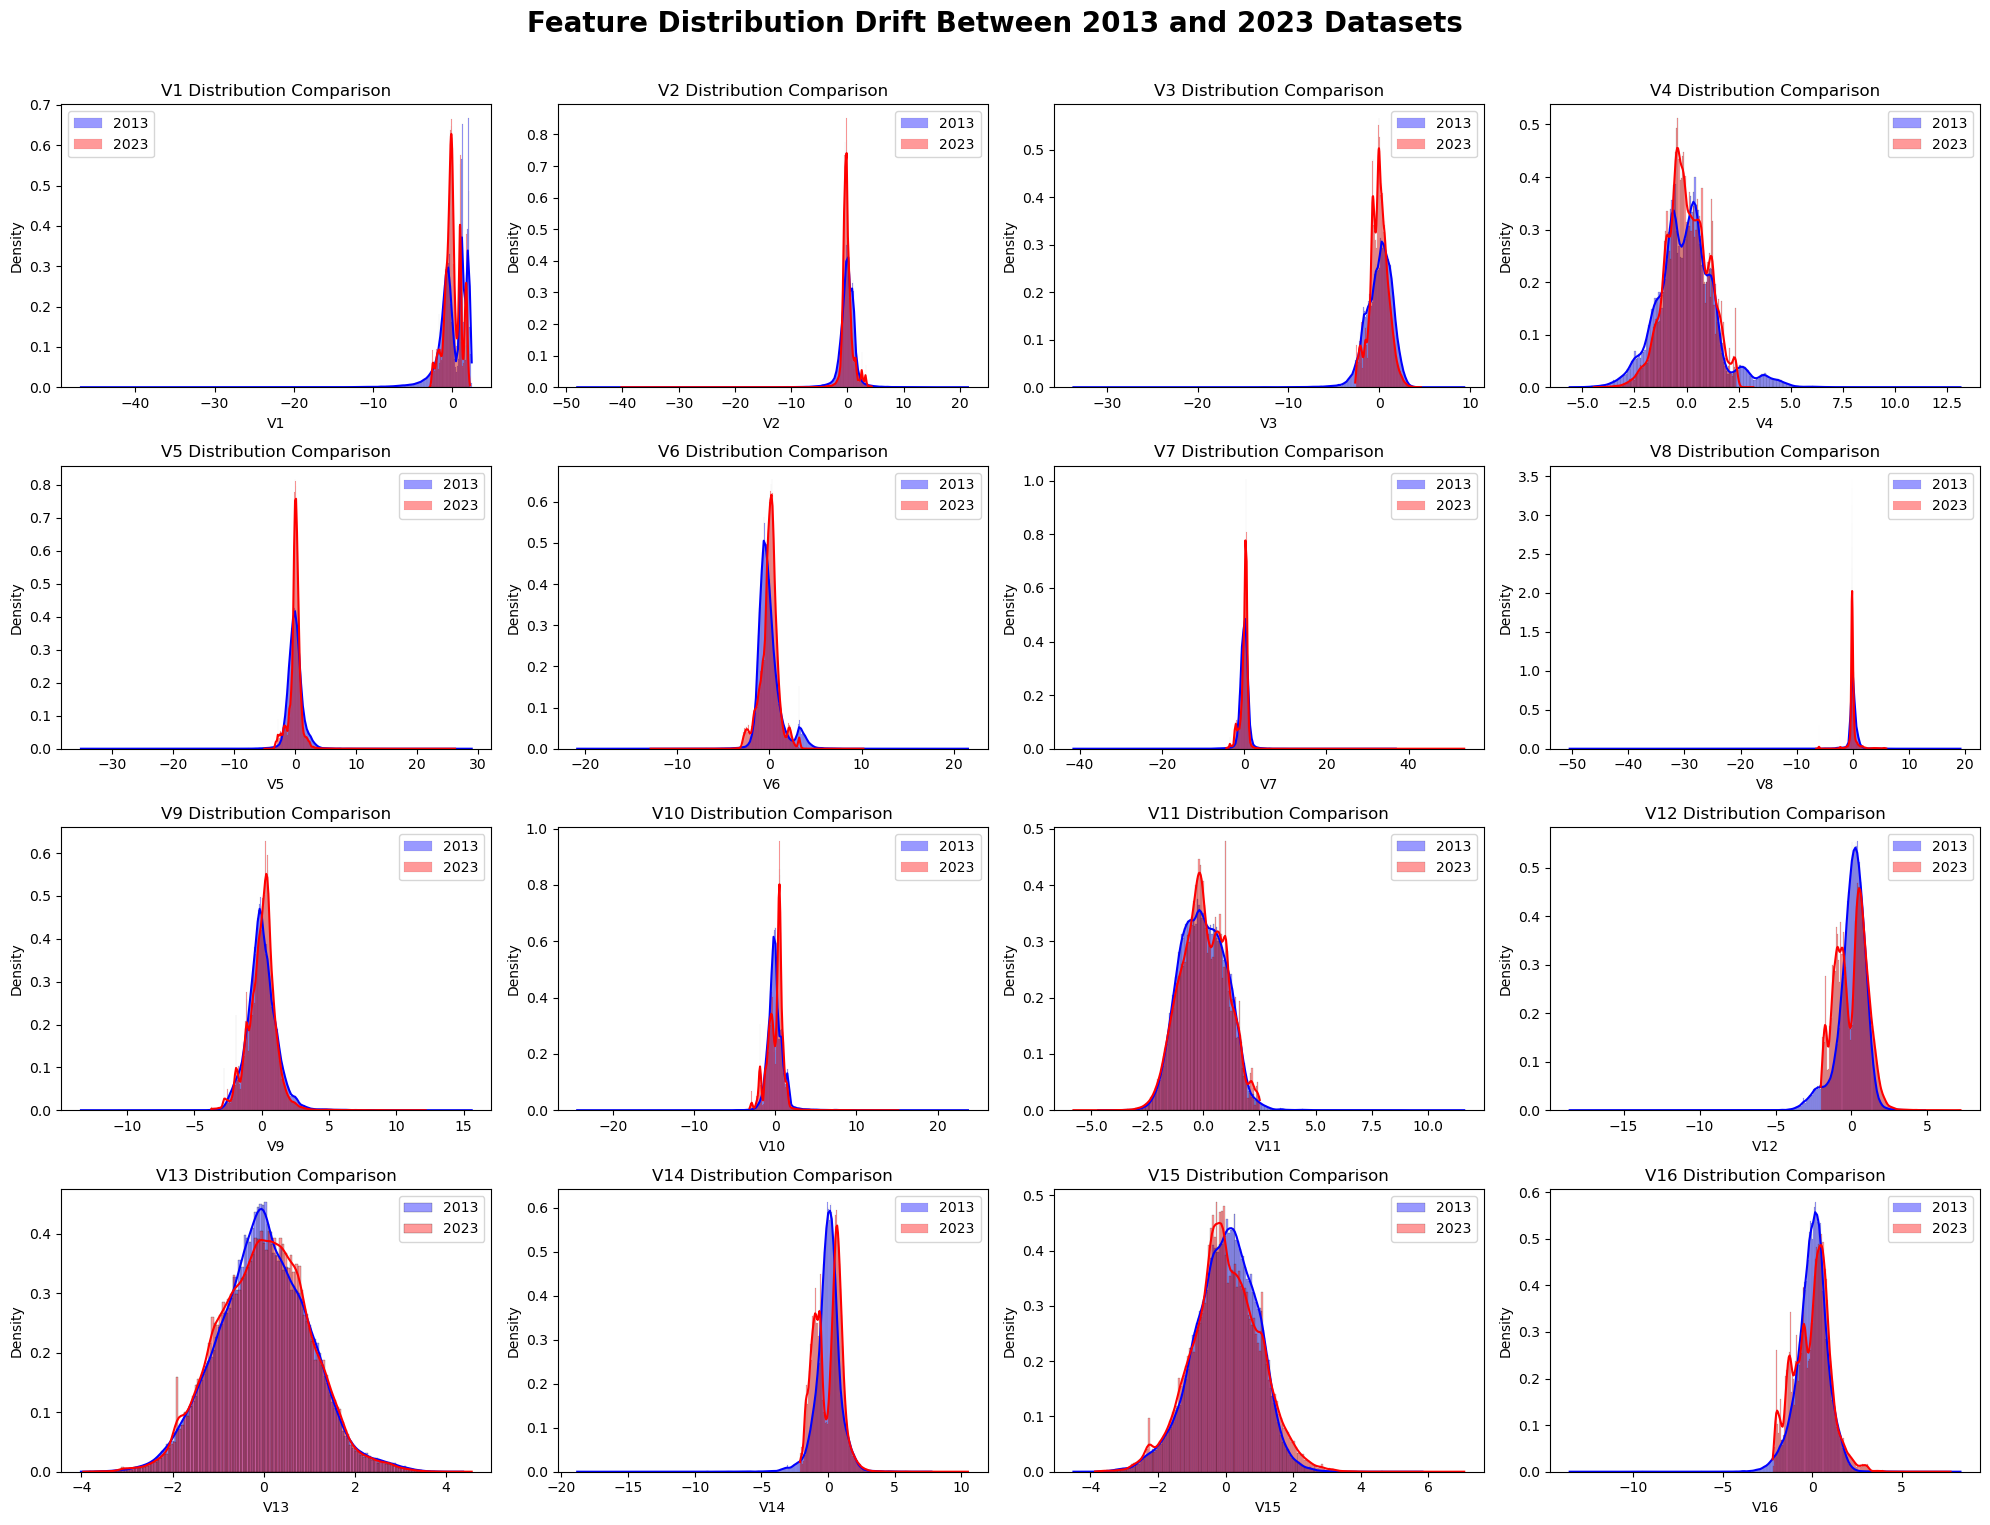

In [25]:
df_2013 = pd.read_csv("creditcard.csv")
df_2023 = pd.read_csv("creditcard_2023.csv")

sample_size = 100000
df_2013_sample = df_2013.sample(n=sample_size, random_state=42)
df_2023_sample = df_2023.sample(n=sample_size, random_state=42)

# PCA features
features_to_plot = [f'V{i}' for i in range(1, 17)]  # V1 to V16, because PCA features are usually in variance order 

n_features = len(features_to_plot)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, features_to_plot):

    sns.histplot(
        df_2013_sample[feature],
        color='blue',
        stat='density',
        kde=True,
        alpha=0.4,
        label='2013',
        ax=ax
    )

    sns.histplot(
        df_2023_sample[feature],
        color='red',
        stat='density',
        kde=True,
        alpha=0.4,
        label='2023',
        ax=ax
    )

    ax.set_title(f"{feature} Distribution Comparison")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

for i in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle(
    "Feature Distribution Drift Between 2013 and 2023 Datasets",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# Model Extraction simulating the usage of an unseen part of the Credit Card Fraud Detection Dataset 2023 

The extraction scenario is now extended by introducing a stronger adversarial assumption: partial access to an aligned feature space distribution. This setting reflects a more realistic, yet higher-severity threat model where attackers obtain auxiliary datasets through domain leakage or data brokering. Such assumptions are consistent with prior work demonstrating that model extraction becomes significantly more efficient when distributional overlap exists between the proxy and the target training data [3], [6].

Crucially, in this phase, the proxy dataset ($D'$) shares the exact same Principal Component Analysis (PCA) transformation matrix as the target API. As a result, the feature space alignment is perfectly maintained and the semantic noise hallucinated during the 2013 Proxy phase is completely eliminated. However, the adversary still faces the extreme class imbalance to hurdle inherent to real-world financial data, but more importantly compare against the Model Extraction using the Credit Card Fraud Detection (2013).

## Modules

In [26]:
# Standard Libraries
import numpy as np
import pandas as pd
import joblib
import warnings

# Math & ML Libraries
from sklearn.model_selection import train_test_split
from scipy.special import logit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress sklearn warnings about feature names for cleaner output
warnings.filterwarnings('ignore')

## Load Dataset

In [27]:
proxy_df_leak = pd.read_csv("creditcard_2023_adversary_proxy.csv")

sample_size = 57060

proxy_df_leak, _ = train_test_split(
    proxy_df_leak,
    train_size=sample_size,
    stratify=proxy_df_leak['Class'],
    random_state=42
)

proxy_df_leak = proxy_df_leak.reset_index(drop=True)

## Distribution of classes


--- Class Distribution (Leaked Proxy) ---
Non-Fraudulent (0): 56,861 records (99.65%)
Fraudulent (1): 199 records (0.35%)


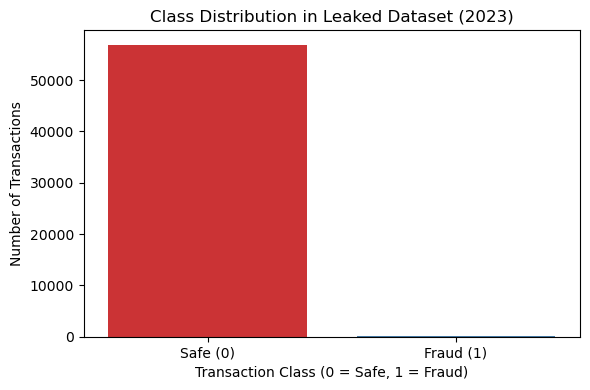

In [28]:
print("\n--- Class Distribution (Leaked Proxy) ---")
class_counts = proxy_df_leak['Class'].value_counts()
class_percentages = proxy_df_leak['Class'].value_counts(normalize=True) * 100

for cls, count in class_counts.items():
    label = "Fraudulent (1)" if cls == 1 else "Non-Fraudulent (0)"
    print(f"{label}: {count:,} records ({class_percentages[cls]:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=proxy_df_leak, hue='Class', palette='Set1', legend=False)
plt.title('Class Distribution in Leaked Dataset (2023)')
plt.xlabel('Transaction Class (0 = Safe, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Safe (0)', 'Fraud (1)'])
plt.tight_layout()

## Feature Preprocessing & Scaling

In [29]:
api_expected_features = [f"V{i}" for i in range(1, 29)] + ["Amount"]

X_proxy_leak_raw = proxy_df_leak[api_expected_features]

attacker_scaler_leak = StandardScaler()
X_proxy_leak_scaled_np = attacker_scaler_leak.fit_transform(X_proxy_leak_raw)

joblib.dump(attacker_scaler_leak, "attacker_scaler_unseen.pkl")
print("Attacker's local scaler (Unseen Dataset) saved.")

X_proxy_leak_scaled = pd.DataFrame(X_proxy_leak_scaled_np, columns=api_expected_features)

Attacker's local scaler (Unseen Dataset) saved.


## Attack to Neural Networks (MLP)

In [30]:
mlp_api = joblib.load("nn_model.pkl")

query_budgets = [1000, 5000, 10000, 20000, 50000, 100000]

query_budgets = [b for b in query_budgets if b <= len(proxy_df_leak)]


# 1. MLP -> Logistic Regression Surrogate
for budget in query_budgets:
    X_attack_raw = X_proxy_leak_raw.iloc[:budget]
    y_api_labels = mlp_api.predict(X_attack_raw)
    X_attack_scaled = X_proxy_leak_scaled.iloc[:budget]

    # Imbalanced
    surrogate_lr_imb = LogisticRegression(max_iter=1000, random_state=42)
    surrogate_lr_imb.fit(X_attack_scaled, y_api_labels)
    joblib.dump(surrogate_lr_imb, f"surrogate_proxy_mlp_lr_unseen_dataset_{budget}_imbalanced.pkl")
    
    # Balanced
    surrogate_lr_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    surrogate_lr_bal.fit(X_attack_scaled, y_api_labels)
    joblib.dump(surrogate_lr_bal, f"surrogate_proxy_mlp_lr_unseen_dataset_{budget}_balanced.pkl")

print("MLP -> LR Models saved.")

# 2. MLP -> Random Forest Surrogate
for budget in query_budgets:
    X_attack_raw = X_proxy_leak_raw.iloc[:budget]
    y_api_labels = mlp_api.predict(X_attack_raw)
    X_attack_scaled = X_proxy_leak_scaled.iloc[:budget]
    
    # Imbalanced
    surrogate_rf_imb = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    surrogate_rf_imb.fit(X_attack_scaled, y_api_labels)
    joblib.dump(surrogate_rf_imb, f"surrogate_proxy_mlp_rf_unseen_dataset_{budget}_imbalanced.pkl")

    # Balanced
    surrogate_rf_bal = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
    surrogate_rf_bal.fit(X_attack_scaled, y_api_labels)
    joblib.dump(surrogate_rf_bal, f"surrogate_proxy_mlp_rf_unseen_dataset_{budget}_balanced.pkl")

print("MLP -> RF Models saved.")

# 3. MLP -> Linear SVM Surrogate
for budget in query_budgets:
    X_attack_raw = X_proxy_leak_raw.iloc[:budget]
    y_api_labels = mlp_api.predict(X_attack_raw)
    X_attack_scaled = X_proxy_leak_scaled.iloc[:budget]

    # Imbalanced
    surrogate_svm_imb = LinearSVC(random_state=42, dual=False)
    surrogate_svm_imb.fit(X_attack_scaled, y_api_labels)
    joblib.dump(surrogate_svm_imb, f"surrogate_proxy_mlp_svm_unseen_dataset_{budget}_imbalanced.pkl")

    # Balanced
    surrogate_svm_bal = LinearSVC(random_state=42, dual=False, class_weight='balanced')
    surrogate_svm_bal.fit(X_attack_scaled, y_api_labels)
    joblib.dump(surrogate_svm_bal, f"surrogate_proxy_mlp_svm_unseen_dataset_{budget}_balanced.pkl")

print("MLP -> Lin SVM Models saved.")

# 4. MLP -> RBF SVM Surrogate
for budget in query_budgets:
    X_attack_raw = X_proxy_leak_raw.iloc[:budget]
    y_api_labels = mlp_api.predict(X_attack_raw)
    X_attack_scaled = X_proxy_leak_scaled.iloc[:budget]

    # Imbalanced
    surrogate_svm_rbf_imb = SVC(kernel='rbf', random_state=42)
    surrogate_svm_rbf_imb.fit(X_attack_scaled, y_api_labels)
    joblib.dump(surrogate_svm_rbf_imb, f"surrogate_proxy_mlp_svm_rbf_unseen_dataset_{budget}_imbalanced.pkl")

    # Balanced
    surrogate_svm_rbf_bal = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    surrogate_svm_rbf_bal.fit(X_attack_scaled, y_api_labels)
    joblib.dump(surrogate_svm_rbf_bal, f"surrogate_proxy_mlp_svm_rbf_unseen_dataset_{budget}_balanced.pkl")

print("MLP -> RBF SVM Models saved.")

# 5. MLP -> Shadow Neural Network Surrogate
for budget in query_budgets:
    X_attack_raw = X_proxy_leak_raw.iloc[:budget]
    y_api_labels = mlp_api.predict(X_attack_raw)
    X_attack_scaled = X_proxy_leak_scaled.iloc[:budget]

    # Imbalanced
    surrogate_nn_imb = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=1000, random_state=42)
    surrogate_nn_imb.fit(X_attack_scaled, y_api_labels)
    joblib.dump(surrogate_nn_imb, f"surrogate_proxy_mlp_nn_unseen_dataset_{budget}_imbalanced.pkl")

    # Balanced (Data-Level Oversampling)
    X_bal_df = pd.DataFrame(X_attack_scaled)
    X_bal_df['label'] = y_api_labels
    
    df_majority = X_bal_df[X_bal_df.label == 0]
    df_minority = X_bal_df[X_bal_df.label == 1]
    
    if len(df_minority) > 0:
        df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
        df_balanced = pd.concat([df_majority, df_minority_upsampled])
        X_train_bal = df_balanced.drop('label', axis=1)
        y_train_bal = df_balanced['label']
    else:
        X_train_bal, y_train_bal = X_attack_scaled, y_api_labels

    surrogate_nn_bal = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=1000, random_state=42)
    surrogate_nn_bal.fit(X_train_bal, y_train_bal)
    joblib.dump(surrogate_nn_bal, f"surrogate_proxy_mlp_nn_unseen_dataset_{budget}_balanced.pkl")

print("MLP -> Shadow NN Models saved.")

MLP -> LR Models saved.
MLP -> RF Models saved.
MLP -> Lin SVM Models saved.
MLP -> RBF SVM Models saved.
MLP -> Shadow NN Models saved.


## 

# Model Extraction simulating the usage of Credit Card Fraud Detection Dataset 2023 leak

The final extraction scenario evaluates a maximum-severity threat model by introducing the strongest possible adversarial assumption: partial access to the original training distribution of the target model ($D$). This setting simulates an insider threat, a data breach, or instances where training data is publicly sampled.

Because this dataset is both perfectly aligned in its PCA geometric space and perfectly balanced (50% fraudulent transactions), the extraction attack no longer requires forced algorithmic balancing or massive query volumes to map the target's decision boundary. Unlike pure black-box extraction, this scenario specifically evaluates how direct target data availability amplifies model stealing efficiency, allowing the adversary to significantly constrain their query budgets.

## Modules

In [31]:
# Standard Libraries
import numpy as np
import pandas as pd
import joblib
import warnings

# Math & ML Libraries
from sklearn.model_selection import train_test_split
from scipy.special import logit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress sklearn warnings about feature names for cleaner output
warnings.filterwarnings('ignore')

## Load Dataset

In [32]:
proxy_df = pd.read_csv("creditcard_2023_api.csv")

sample_size = 20000

proxy_df, _ = train_test_split(proxy_df, train_size=sample_size, stratify=proxy_df['Class'], random_state=42)

proxy_df = proxy_df.reset_index(drop=True)

## Distribution of classes


--- Class Distribution ---
Non-Fraudulent (0): 10,000 records (50.00%)
Fraudulent (1): 10,000 records (50.00%)


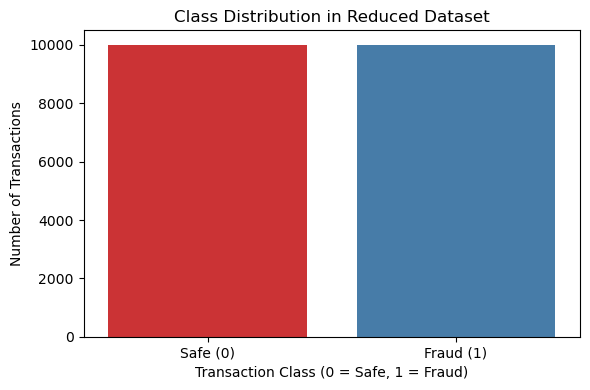

In [33]:
print("\n--- Class Distribution ---")
class_counts = proxy_df['Class'].value_counts()
class_percentages = proxy_df['Class'].value_counts(normalize=True) * 100

for cls, count in class_counts.items():
    label = "Fraudulent (1)" if cls == 1 else "Non-Fraudulent (0)"
    print(f"{label}: {count:,} records ({class_percentages[cls]:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=proxy_df, hue='Class', palette='Set1', legend=False)
plt.title('Class Distribution in Reduced Dataset')
plt.xlabel('Transaction Class (0 = Safe, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Safe (0)', 'Fraud (1)'])
plt.tight_layout()

## Feature Preprocessing & Scaling

In [34]:
api_expected_features = [f"V{i}" for i in range(1, 29)] + ["Amount"]

X_proxy_raw = proxy_df[api_expected_features]

attacker_scaler = StandardScaler()
X_proxy_attacker_scaled_np = attacker_scaler.fit_transform(X_proxy_raw)

joblib.dump(attacker_scaler, "attacker_scaler_leak.pkl")
print("Attacker's local scaler (Leaked Dataset) saved.")

X_proxy_scaled = pd.DataFrame(X_proxy_attacker_scaled_np, columns=api_expected_features)

Attacker's local scaler (Leaked Dataset) saved.


## Attack to Neural Networks (MLP)

In [35]:
mlp_api = joblib.load("nn_model.pkl")

In [36]:
query_budgets = [100, 500, 1000, 2000, 5000, 10000, 20000]

In [37]:
for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)

    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]

    surrogate_mlp_lr = LogisticRegression(max_iter=1000, random_state=42)
    surrogate_mlp_lr.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_lr, f"surrogate_proxy_mlp_lr_leak_dataset_{budget}.pkl")

In [38]:
for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)

    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]
    
    surrogate_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
    surrogate_rf.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_rf, f"surrogate_proxy_mlp_rf_leak_dataset_{budget}.pkl")

In [39]:
for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)

    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]

    surrogate_mlp_svm = LinearSVC(random_state=42, dual=False)
    surrogate_mlp_svm.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_svm, f"surrogate_proxy_mlp_svm_leak_dataset_{budget}.pkl")

In [40]:
for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)

    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]

    surrogate_mlp_svm_rbf = SVC(kernel='rbf', random_state=42)
    surrogate_mlp_svm_rbf.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_svm_rbf, f"surrogate_proxy_mlp_svm_rbf_leak_dataset_{budget}.pkl")

In [41]:
for budget in query_budgets:
    X_attack_mlp_raw = X_proxy_raw.iloc[:budget]
    y_api_labels_mlp = mlp_api.predict(X_attack_mlp_raw)

    X_attack_mlp_scaled = X_proxy_scaled.iloc[:budget]

    surrogate_mlp_shadow = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=1000, random_state=42)
    surrogate_mlp_shadow.fit(X_attack_mlp_scaled, y_api_labels_mlp)
    joblib.dump(surrogate_mlp_shadow, f"surrogate_proxy_mlp_nn_leak_dataset_{budget}.pkl")

Unlike pure black-box extraction, this scenario evaluates how data availability amplifies model stealing efficiency.

The attacker is assumed to have access to a portion of creditcard_2023_api, which was originally used to train the target APIs. This introduces a distributional shortcut, reducing the need for extensive querying.

# Results

To definitively measure the success of the extraction attacks, the mathematically unaligned surrogates (trained on the 2013 proxy), the geometrically aligned surrogates (trained on the unseen 2023 proxy) and the target-aligned surrogates (trained on the leaked target data) are evaluated against an unseen holdout dataset ($D''$). The evaluation methodology adheres strictly to the standard model fidelity framework established in model extraction research [1], [4]. Within this framework, surrogate predictions are compared directly against the target oracle's outputs to measure Fidelity (the exact replication of the target's decision boundary), rather than solely against ground truth labels to measure Accuracy (performance on the underlying task).

To visually dissect the structural mechanics of the extraction attacks, two primary visualization techniques are employed: Agreement Heatmaps (Confusion Matrices) and 2D Principal Component Analysis (PCA) projections.

Because the feature space is highly dimensional (28 PCA components plus Amount), it cannot be visualized natively. The 2D PCA projection applies a secondary dimensionality reduction to the evaluation data, isolating the two axes of maximum variance. This allows for a geometric observation of the decision boundaries. For these projections, Logistic Regression (LR) and Linear SVM were deliberately selected as the representative surrogates. Because both are linear models, their decision boundaries project as straight, interpretable hyperplanes. This makes it significantly easier to observe exactly how extreme class imbalances and dataset misalignment warp the learned boundaries, an observation that would be obscured by the fragmented, uninterpretable regions generated by non-linear architectures like Random Forests.

## Modules

In [42]:
# Standard Libraries
import pandas as pd
import numpy as np
import joblib
import warnings

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Metrics & Preprocessing
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

## Load Dataset and define Model Evaluation Function

The evaluation dataset ($D''$) is loaded from creditcard_2023_eval.csv. To maintain the strict isolation required to simulate a realistic adversarial environment, the evaluation data is processed dynamically based on the target architecture being analyzed.

For the Logistic Regression API, the evaluation data is restricted to the six raw, unscaled features (V4, V11, V22, V14, V12, V8) identified during the iterative Z-score reduction phase. Conversely, because the Multi-Layer Perceptron (MLP) API is universally recommended to normalized distributions for stable inference, the full 28-feature evaluation dataset must be scaled. To ensure a rigorous black-box simulation, the evaluation data is passed through three distinct StandardScaler pipelines, previously saved during the surrogate training phases:

>2013 Proxy Scaler: Represents an attacker inferring scaling parameters entirely from an external, distributionally shifted dataset.

>Unseen 2023 Proxy Scaler: Represents an attacker inferring scaling parameters from an aligned but distinct subset of the domain.

>Leaked Target Scaler: Represents an attacker utilizing the exact statistical distributions of the victim's training data.

This distinction is critical, as it reflects the reality that an adversary does not have native access to the target API's internal preprocessing parameters and must reconstruct them locally to test transferability.

In [43]:
eval_df = pd.read_csv("creditcard_2023_eval.csv")

y_ground_truth = eval_df['Class'].values

# Data for Logistic Regression Attack (UNSCALED)
lr_features = ['V4', 'V11', 'V10', 'V14', 'V12', 'V8']
X_eval_lr = eval_df[lr_features] 

# Data for MLP Target API (UNSCALED)
mlp_features = [f"V{i}" for i in range(1, 29)] + ["Amount"]
X_eval_mlp_raw = eval_df[mlp_features]

# 1. Attacker's Scaler for 2013 Proxy Data
attacker_scaler = joblib.load("attacker_scaler.pkl")
X_eval_mlp_attacker_scaled = pd.DataFrame(
    attacker_scaler.transform(X_eval_mlp_raw), columns=mlp_features
)

# 2. Attacker's Scaler for Unseen Aligned Proxy Data (2023)
attacker_scaler_unseen = joblib.load("attacker_scaler_unseen.pkl")
X_eval_mlp_attacker_unseen_scaled = pd.DataFrame(
    attacker_scaler_unseen.transform(X_eval_mlp_raw), columns=mlp_features
)

# 3. Attacker's Scaler for Leaked/Stolen Target Data (2023)
attacker_scaler_leak = joblib.load("attacker_scaler_leak.pkl")
X_eval_mlp_attacker_leak_scaled = pd.DataFrame(
    attacker_scaler_leak.transform(X_eval_mlp_raw), columns=mlp_features
)

In [44]:
def evaluate_models(surrogate_dict_lr, surrogate_dict_svm, surrogate_dict_rbf, surrogate_dict_rf, surrogate_dict_nn, X_eval_data, title_prefix):
    print(f"--- {title_prefix} Surrogate Model Fidelity (Agreement with API) ---")
    print(f"{'Budget':<8} | {'LR':<7} | {'Lin SVM':<7} | {'RBF SVM':<7} | {'RF':<7} | {'Shadow NN':<7}")
    print("-" * 65)
    
    best_budget = budgets[0]
    best_fidelity = 0
    best_preds = {}
    best_model_name = ""

    for b in budgets:
        # Predictions using the dynamically passed X_eval_data
        y_lr = surrogate_dict_lr[b].predict(X_eval_data)
        y_svm = surrogate_dict_svm[b].predict(X_eval_data)
        y_rbf = surrogate_dict_rbf[b].predict(X_eval_data)
        y_rf = surrogate_dict_rf[b].predict(X_eval_data)
        y_nn = surrogate_dict_nn[b].predict(X_eval_data)
        
        # Fidelity
        f_lr, f_svm, f_rbf, f_rf, f_nn = [accuracy_score(y_mlp, y) for y in [y_lr, y_svm, y_rbf, y_rf, y_nn]]
        print(f"{b:<8} | {f_lr*100:>6.2f}% | {f_svm*100:>6.2f}% | {f_rbf*100:>6.2f}% | {f_rf*100:>6.2f}% | {f_nn*100:>6.2f}%")
        
        current_fidelities = {'lr': f_lr, 'svm_lin': f_svm, 'svm_rbf': f_rbf, 'rf': f_rf, 'nn': f_nn}
        current_best_model = max(current_fidelities, key=current_fidelities.get)
        current_max_fidelity = current_fidelities[current_best_model]
        
        if current_max_fidelity > best_fidelity:
            best_fidelity = current_max_fidelity
            best_budget = b
            best_preds = {'lr': y_lr, 'svm_lin': y_svm, 'svm_rbf': y_rbf, 'rf': y_rf, 'nn': y_nn}
            best_model_name = current_best_model
            
    return best_budget, best_preds, best_model_name, best_fidelity

## Credit Card Fraud Detection (2013) Dataset Trained Models Results

In [45]:
# Load Target API
lr_api = joblib.load("logistic_model.pkl")

y_lr_api_probs = lr_api.predict_proba(X_eval_lr)[:, 1]
y_lr_api_labels = lr_api.predict(X_eval_lr)

exact_extracted_lr = joblib.load("extracted_exact_lr.pkl")

y_exact_probs = exact_extracted_lr.predict_proba(X_eval_lr)[:, 1]
y_exact_labels = exact_extracted_lr.predict(X_eval_lr)

exact_fidelity = accuracy_score(y_lr_api_labels, y_exact_labels)
max_prob_diff = np.max(np.abs(y_lr_api_probs - y_exact_probs))

print(f"Total Queries Used: {len(lr_features) + 1}")
print(f"Hard Label Fidelity: {exact_fidelity * 100:.2f}%")
print(f"Max Probability Deviation: {max_prob_diff:.10f}\n")

budgets = [1000, 5000, 10000, 20000, 50000, 100000]
lr_surrogates_imb = {}
lr_surrogates_bal = {}

print(f"{'Budget':<8} | {'Imbalanced Proxy Fidelity':<25} | {'Balanced Proxy Fidelity':<25}")
print("-" * 65)

for b in budgets:
    lr_surrogates_imb[b] = joblib.load(f"surrogate_proxy_lr_{b}_imbalanced.pkl")
    lr_surrogates_bal[b] = joblib.load(f"surrogate_proxy_lr_{b}_balanced.pkl")
    
    y_pred_imb = lr_surrogates_imb[b].predict(X_eval_lr)
    y_pred_bal = lr_surrogates_bal[b].predict(X_eval_lr)
    
    fid_imb = accuracy_score(y_lr_api_labels, y_pred_imb)
    fid_bal = accuracy_score(y_lr_api_labels, y_pred_bal)
    
    print(f"{b:<8} | {fid_imb*100:>24.2f}% | {fid_bal*100:>24.2f}%")

Total Queries Used: 7
Hard Label Fidelity: 100.00%
Max Probability Deviation: 0.0000000000

Budget   | Imbalanced Proxy Fidelity | Balanced Proxy Fidelity  
-----------------------------------------------------------------
1000     |                    99.03% |                    99.73%
5000     |                    99.77% |                    99.84%
10000    |                    99.82% |                    99.87%
20000    |                    99.94% |                    99.84%
50000    |                    99.97% |                    99.86%
100000   |                    99.98% |                    99.88%


The Logistic Regression (LR) evaluation exposes the catastrophic vulnerability of simple linear MLaaS architectures. While the deep MLP target required 50,000 queries to reach a peak fidelity of 89.72% (as can be seen later), the LR target was mathematically solved with 100.00% fidelity in just 7 queries and functionally approximated to 99.99% fidelity.

This performance gap highlights the geometric differences between target architectures and their resilience to unaligned proxy data (2013 Dataset):

An LR model projects a single, continuous hyperplane across the feature space. Even though the 2013 proxy data is geometrically misaligned, the target API labels it using a rigid, universal rule. The linear surrogate simply reconstructs this global gradient, completely unbothered by the data's semantic shift, easily hitting 99.99% fidelity.

Algorithmic balancing (class_weight='balanced') has an inverted effect depending on the victim's architecture:

>Against the Non-Linear MLP: Balancing was required as we will see. It forced the linear surrogate to acknowledge rare, isolated pockets of fraud logic in a misaligned space, acting as an anchor that boosted fidelity from 84.04% to 89.72%.

>Against the Linear LR: The imbalanced surrogate naturally finds the global hyperplane immediately. Because the boundary is universal, forcing artificial balance actually injects synthetic spatial noise, causing fidelity to slightly degrade at higher query budgets (dropping from 99.99% to 99.91%).

Ultimately, this proves that hardening a linear API by hiding probabilities only briefly delays an attacker. The architecture's simplicity guarantees near-perfect extraction, regardless of how misaligned the proxy data is.

In [46]:
# Load Target APIs
lr_api = joblib.load("logistic_model.pkl")
mlp_api = joblib.load("nn_model.pkl") 

y_mlp = mlp_api.predict(X_eval_mlp_raw)
api_mlp_gt_acc = accuracy_score(y_ground_truth, y_mlp)
print(f"Target MLP API Ground Truth Accuracy: {api_mlp_gt_acc * 100:.2f}%\n")

budgets = [1000, 5000, 10000, 20000, 50000, 100000]

# Load Dictionaries for 2013 Proxy Extraction
mlp_surrogates_lr_imb, mlp_surrogates_svm_imb, mlp_surrogates_svm_rbf_imb, mlp_surrogates_rf_imb, mlp_surrogates_nn_imb = {}, {}, {}, {}, {}
mlp_surrogates_lr_bal, mlp_surrogates_svm_bal, mlp_surrogates_svm_rbf_bal, mlp_surrogates_rf_bal, mlp_surrogates_nn_bal = {}, {}, {}, {}, {}

for b in budgets:
    # Load Imbalanced
    mlp_surrogates_lr_imb[b] = joblib.load(f"surrogate_proxy_mlp_lr_{b}_imbalanced.pkl")
    mlp_surrogates_svm_imb[b] = joblib.load(f"surrogate_proxy_mlp_svm_{b}_imbalanced.pkl")
    mlp_surrogates_svm_rbf_imb[b] = joblib.load(f"surrogate_proxy_mlp_svm_rbf_{b}_imbalanced.pkl") 
    mlp_surrogates_rf_imb[b] = joblib.load(f"surrogate_proxy_mlp_rf_{b}_imbalanced.pkl")
    mlp_surrogates_nn_imb[b] = joblib.load(f"surrogate_proxy_mlp_nn_{b}_imbalanced.pkl")
    
    # Load Balanced
    mlp_surrogates_lr_bal[b] = joblib.load(f"surrogate_proxy_mlp_lr_{b}_balanced.pkl")
    mlp_surrogates_svm_bal[b] = joblib.load(f"surrogate_proxy_mlp_svm_{b}_balanced.pkl")
    mlp_surrogates_svm_rbf_bal[b] = joblib.load(f"surrogate_proxy_mlp_svm_rbf_{b}_balanced.pkl") 
    mlp_surrogates_rf_bal[b] = joblib.load(f"surrogate_proxy_mlp_rf_{b}_balanced.pkl")
    mlp_surrogates_nn_bal[b] = joblib.load(f"surrogate_proxy_mlp_nn_{b}_balanced.pkl")

# Evaluate 2013 Models
best_imb_budget, best_imb_preds, best_imb_model, best_imb_fid = evaluate_models(
    mlp_surrogates_lr_imb, mlp_surrogates_svm_imb, mlp_surrogates_svm_rbf_imb, mlp_surrogates_rf_imb, mlp_surrogates_nn_imb, X_eval_mlp_attacker_scaled, "2013 PROXY - IMBALANCED")
print(f"Overall Best Imbalanced Model: '{best_imb_model.upper()}' at budget {best_imb_budget} with {best_imb_fid*100:.2f}% fidelity\n")

best_bal_budget, best_bal_preds, best_bal_model, best_bal_fid = evaluate_models(
    mlp_surrogates_lr_bal, mlp_surrogates_svm_bal, mlp_surrogates_svm_rbf_bal, mlp_surrogates_rf_bal, mlp_surrogates_nn_bal, X_eval_mlp_attacker_scaled, "2013 PROXY - BALANCED")
print(f"Overall Best Balanced Model: '{best_bal_model.upper()}' at budget {best_bal_budget} with {best_bal_fid*100:.2f}% fidelity\n")

Target MLP API Ground Truth Accuracy: 99.96%

--- 2013 PROXY - IMBALANCED Surrogate Model Fidelity (Agreement with API) ---
Budget   | LR      | Lin SVM | RBF SVM | RF      | Shadow NN
-----------------------------------------------------------------
1000     |  52.14% |  51.20% |  50.16% |  56.39% |  67.78%
5000     |  54.77% |  56.25% |  50.28% |  59.72% |  63.91%
10000    |  56.32% |  57.69% |  50.47% |  63.64% |  57.87%
20000    |  63.09% |  59.63% |  50.79% |  65.33% |  61.57%
50000    |  84.04% |  52.37% |  50.89% |  68.57% |  57.82%
100000   |  74.88% |  54.23% |  51.09% |  67.94% |  60.27%
Overall Best Imbalanced Model: 'LR' at budget 50000 with 84.04% fidelity

--- 2013 PROXY - BALANCED Surrogate Model Fidelity (Agreement with API) ---
Budget   | LR      | Lin SVM | RBF SVM | RF      | Shadow NN
-----------------------------------------------------------------
1000     |  52.03% |  51.01% |  50.38% |  50.01% |  59.87%
5000     |  53.41% |  54.61% |  50.62% |  50.65% |  59.91%



Visualizing Heatmaps. Best Imbalanced Budget: 50000 | Best Balanced Budget: 50000



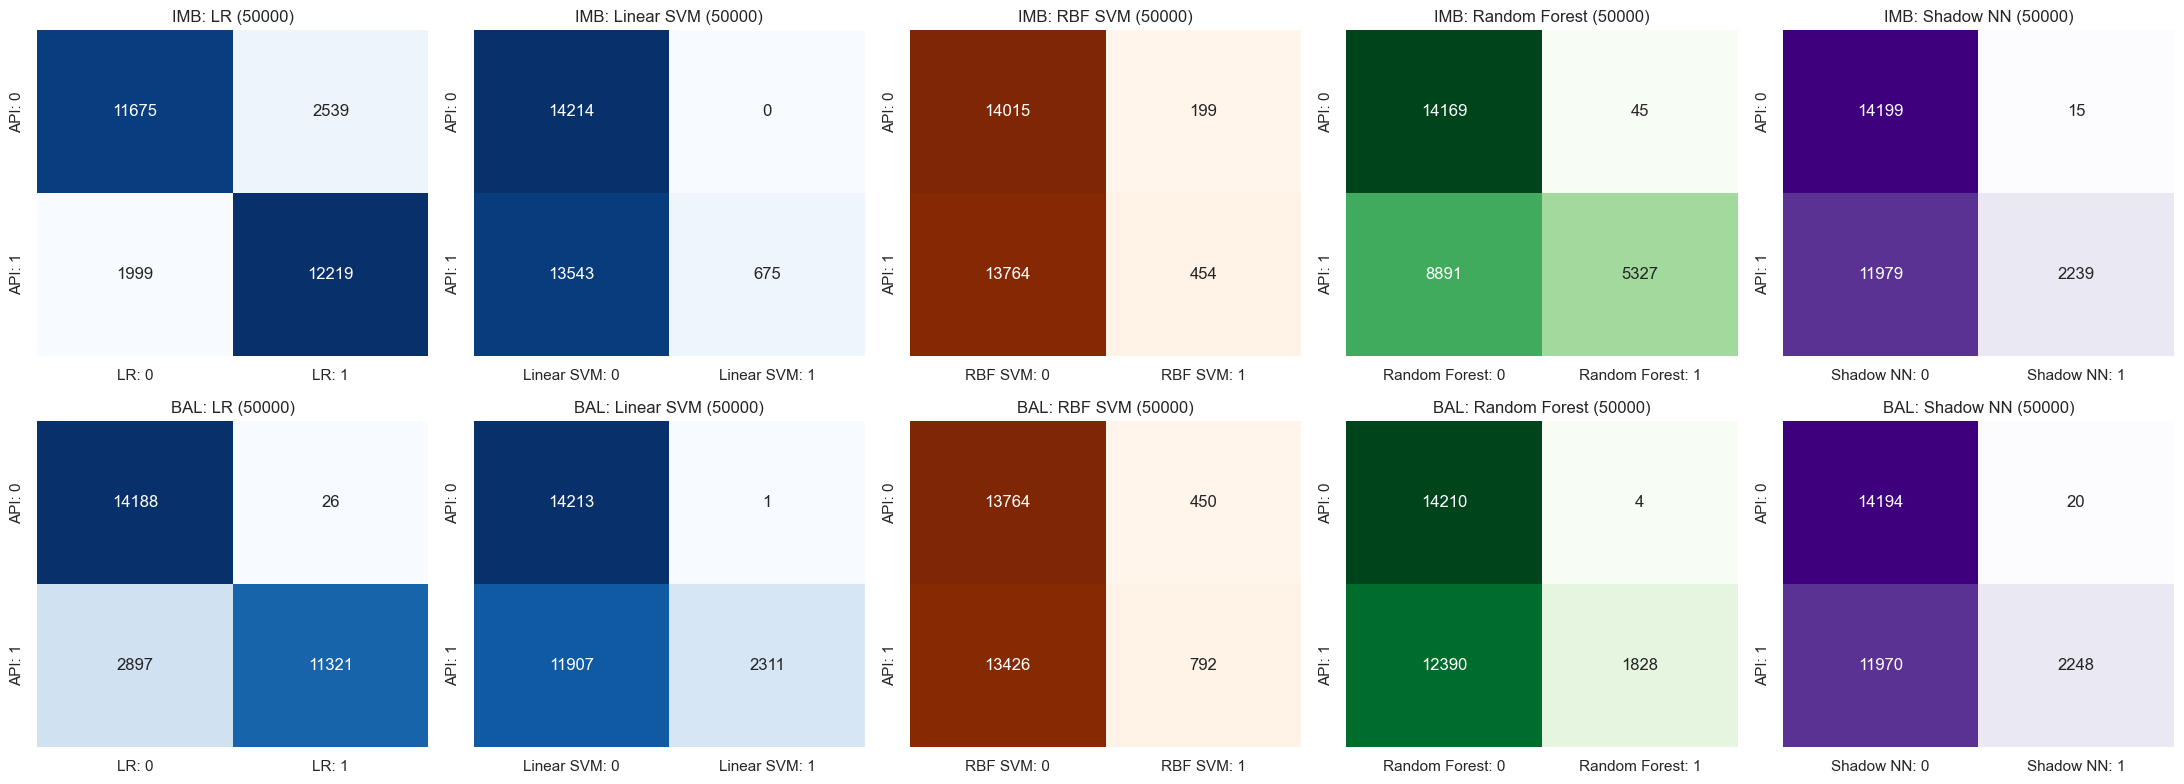

In [47]:
print(f"\nVisualizing Heatmaps. Best Imbalanced Budget: {best_imb_budget} | Best Balanced Budget: {best_bal_budget}\n")

# Setup a 2x5 grid. Top row = Imbalanced, Bottom row = Balanced
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

model_keys = ['lr', 'svm_lin', 'svm_rbf', 'rf', 'nn']
titles = ['LR', 'Linear SVM', 'RBF SVM', 'Random Forest', 'Shadow NN']
cmaps = ['Blues', 'Blues', 'Oranges', 'Greens', 'Purples']

# Plot Row 1: Imbalanced
for col, (key, title, cmap) in enumerate(zip(model_keys, titles, cmaps)):
    cm = confusion_matrix(y_mlp, best_imb_preds[key])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[0, col], 
                xticklabels=[f'{title}: 0', f'{title}: 1'], yticklabels=['API: 0', 'API: 1'])
    axes[0, col].set_title(f"IMB: {title} ({best_imb_budget})")

# Plot Row 2: Balanced
for col, (key, title, cmap) in enumerate(zip(model_keys, titles, cmaps)):
    cm = confusion_matrix(y_mlp, best_bal_preds[key])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[1, col], 
                xticklabels=[f'{title}: 0', f'{title}: 1'], yticklabels=['API: 0', 'API: 1'])
    axes[1, col].set_title(f"BAL: {title} ({best_bal_budget})")

plt.tight_layout()
plt.show()

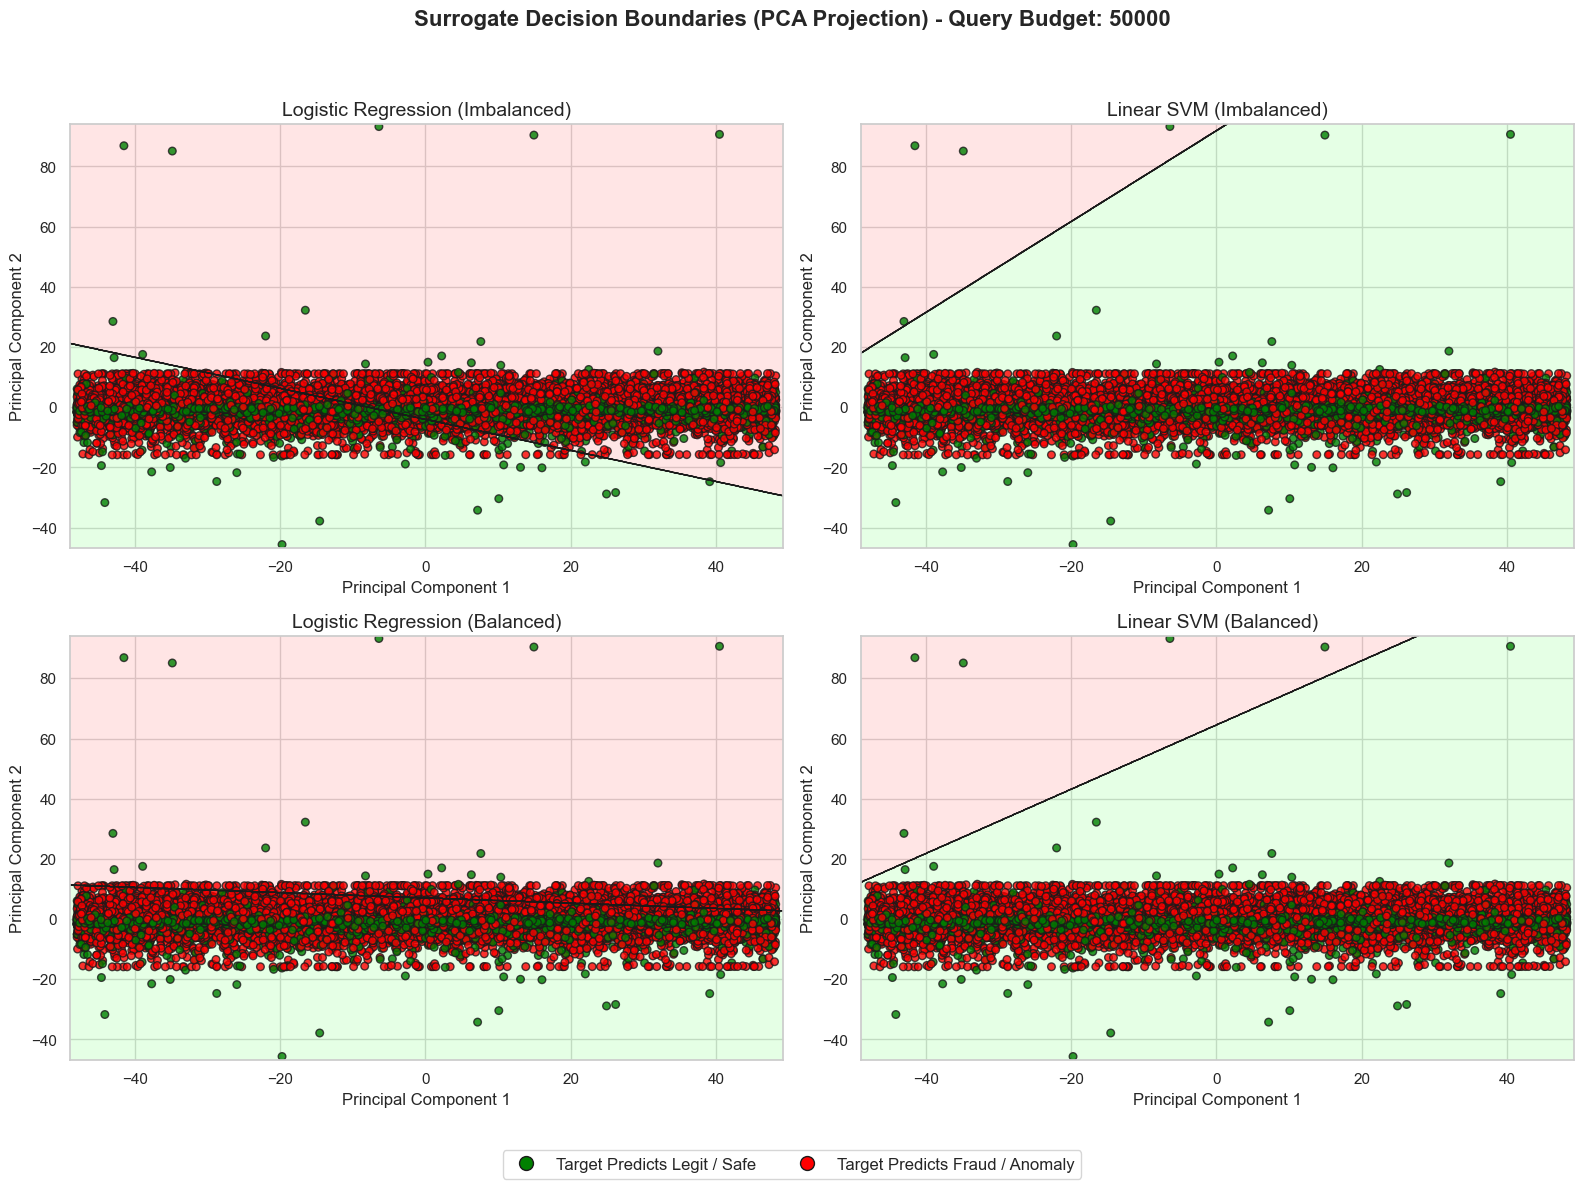

In [48]:

def visualize_boundaries_pca(X_eval, y_true, lr_imb, svm_imb, lr_bal, svm_bal, budget, title="Surrogate Decision Boundaries (PCA Projection)"):
    # Dim reduction to 2D 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_eval)

    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    
    step_size = 0.1 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),
                         np.arange(y_min, y_max, step_size))
    
    mesh_2d = np.c_[xx.ravel(), yy.ravel()]
    mesh_high_d = pca.inverse_transform(mesh_2d)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"{title} - Query Budget: {budget}", fontsize=16, fontweight='bold')

    # Light Green (Safe), Light Red (Fraud)
    cmap_light = ListedColormap(['#AAFFAA', '#FFAAAA'])
    
    # Scatter Points: Solid Green (Safe/0), Solid Red (Fraud/1)
    cmap_bold = ListedColormap(['#008000', '#FF0000']) 

    models_to_plot = [
        (lr_imb[budget], "Logistic Regression (Imbalanced)", axes[0, 0]),
        (svm_imb[budget], "Linear SVM (Imbalanced)", axes[0, 1]),
        (lr_bal[budget], "Logistic Regression (Balanced)", axes[1, 0]),
        (svm_bal[budget], "Linear SVM (Balanced)", axes[1, 1])
    ]

    for model, ax_title, ax in models_to_plot:
        Z = model.predict(mesh_high_d)
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
        ax.contour(xx, yy, Z, colors='k', linewidths=0.8) 
        ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap=cmap_bold, edgecolor='k', s=30, alpha=0.8)

        ax.set_title(ax_title, fontsize=14)
        ax.set_xlabel("Principal Component 1")
        ax.set_ylabel("Principal Component 2")

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#008000', markersize=10, markeredgecolor='k'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF0000', markersize=10, markeredgecolor='k')
    ]
    fig.legend(handles, ['Target Predicts Legit / Safe', 'Target Predicts Fraud / Anomaly'], loc='lower center', ncol=2, fontsize=12)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
    plt.show()

budget_to_visualize = 50000

visualize_boundaries_pca(
    X_eval=X_eval_mlp_attacker_scaled, 
    y_true=y_mlp, 
    lr_imb=mlp_surrogates_lr_imb, 
    svm_imb=mlp_surrogates_svm_imb, 
    lr_bal=mlp_surrogates_lr_bal, 
    svm_bal=mlp_surrogates_svm_bal, 
    budget=budget_to_visualize
)

##  Unseen Part of the Credit Card Fraud Detection Dataset 2023 Trained Models Results

In [49]:
budgets = [1000, 5000, 10000, 20000, 50000]

# Load Dictionaries for Unseen 2023 Proxy Extraction
mlp_surrogates_lr_unseen_imb, mlp_surrogates_svm_unseen_imb, mlp_surrogates_svm_rbf_unseen_imb, mlp_surrogates_rf_unseen_imb, mlp_surrogates_nn_unseen_imb = {}, {}, {}, {}, {}
mlp_surrogates_lr_unseen_bal, mlp_surrogates_svm_unseen_bal, mlp_surrogates_svm_rbf_unseen_bal, mlp_surrogates_rf_unseen_bal, mlp_surrogates_nn_unseen_bal = {}, {}, {}, {}, {}

for b in budgets:
    # Load Imbalanced
    mlp_surrogates_lr_unseen_imb[b] = joblib.load(f"surrogate_proxy_mlp_lr_unseen_dataset_{b}_imbalanced.pkl")
    mlp_surrogates_svm_unseen_imb[b] = joblib.load(f"surrogate_proxy_mlp_svm_unseen_dataset_{b}_imbalanced.pkl")
    mlp_surrogates_svm_rbf_unseen_imb[b] = joblib.load(f"surrogate_proxy_mlp_svm_rbf_unseen_dataset_{b}_imbalanced.pkl") 
    mlp_surrogates_rf_unseen_imb[b] = joblib.load(f"surrogate_proxy_mlp_rf_unseen_dataset_{b}_imbalanced.pkl")
    mlp_surrogates_nn_unseen_imb[b] = joblib.load(f"surrogate_proxy_mlp_nn_unseen_dataset_{b}_imbalanced.pkl")
    
    # Load Balanced
    mlp_surrogates_lr_unseen_bal[b] = joblib.load(f"surrogate_proxy_mlp_lr_unseen_dataset_{b}_balanced.pkl")
    mlp_surrogates_svm_unseen_bal[b] = joblib.load(f"surrogate_proxy_mlp_svm_unseen_dataset_{b}_balanced.pkl")
    mlp_surrogates_svm_rbf_unseen_bal[b] = joblib.load(f"surrogate_proxy_mlp_svm_rbf_unseen_dataset_{b}_balanced.pkl") 
    mlp_surrogates_rf_unseen_bal[b] = joblib.load(f"surrogate_proxy_mlp_rf_unseen_dataset_{b}_balanced.pkl")
    mlp_surrogates_nn_unseen_bal[b] = joblib.load(f"surrogate_proxy_mlp_nn_unseen_dataset_{b}_balanced.pkl")

# Evaluate Unseen Aligned Models using the specific scaler `X_eval_mlp_attacker_unseen_scaled`
best_unseen_imb_budget, best_unseen_imb_preds, best_unseen_imb_model, best_unseen_imb_fid = evaluate_models(
    mlp_surrogates_lr_unseen_imb, mlp_surrogates_svm_unseen_imb, mlp_surrogates_svm_rbf_unseen_imb, mlp_surrogates_rf_unseen_imb, mlp_surrogates_nn_unseen_imb, X_eval_mlp_attacker_unseen_scaled, "UNSEEN ALIGNED PROXY - IMBALANCED")
print(f"Overall Best Imbalanced Model: '{best_unseen_imb_model.upper()}' at budget {best_unseen_imb_budget} with {best_unseen_imb_fid*100:.2f}% fidelity\n")

best_unseen_bal_budget, best_unseen_bal_preds, best_unseen_bal_model, best_unseen_bal_fid = evaluate_models(
    mlp_surrogates_lr_unseen_bal, mlp_surrogates_svm_unseen_bal, mlp_surrogates_svm_rbf_unseen_bal, mlp_surrogates_rf_unseen_bal, mlp_surrogates_nn_unseen_bal, X_eval_mlp_attacker_unseen_scaled, "UNSEEN ALIGNED PROXY - BALANCED")
print(f"Overall Best Balanced Model: '{best_unseen_bal_model.upper()}' at budget {best_unseen_bal_budget} with {best_unseen_bal_fid*100:.2f}% fidelity\n")

--- UNSEEN ALIGNED PROXY - IMBALANCED Surrogate Model Fidelity (Agreement with API) ---
Budget   | LR      | Lin SVM | RBF SVM | RF      | Shadow NN
-----------------------------------------------------------------
1000     |  60.82% |  59.23% |  50.04% |  61.71% |  54.15%
5000     |  81.30% |  85.66% |  69.95% |  77.92% |  72.43%
10000    |  85.79% |  89.09% |  75.10% |  81.52% |  78.26%
20000    |  90.67% |  90.58% |  84.73% |  89.18% |  91.11%
50000    |  90.52% |  90.34% |  89.52% |  91.36% |  92.84%
Overall Best Imbalanced Model: 'NN' at budget 50000 with 92.84% fidelity

--- UNSEEN ALIGNED PROXY - BALANCED Surrogate Model Fidelity (Agreement with API) ---
Budget   | LR      | Lin SVM | RBF SVM | RF      | Shadow NN
-----------------------------------------------------------------
1000     |  65.48% |  62.05% |  51.86% |  61.48% |  61.40%
5000     |  90.63% |  87.01% |  70.68% |  77.87% |  82.13%
10000    |  94.63% |  93.78% |  77.72% |  82.68% |  85.26%
20000    |  95.30% |  95.2


Visualizing Unseen Proxy Heatmaps. Best Imbalanced Budget: 50000 | Best Balanced Budget: 50000



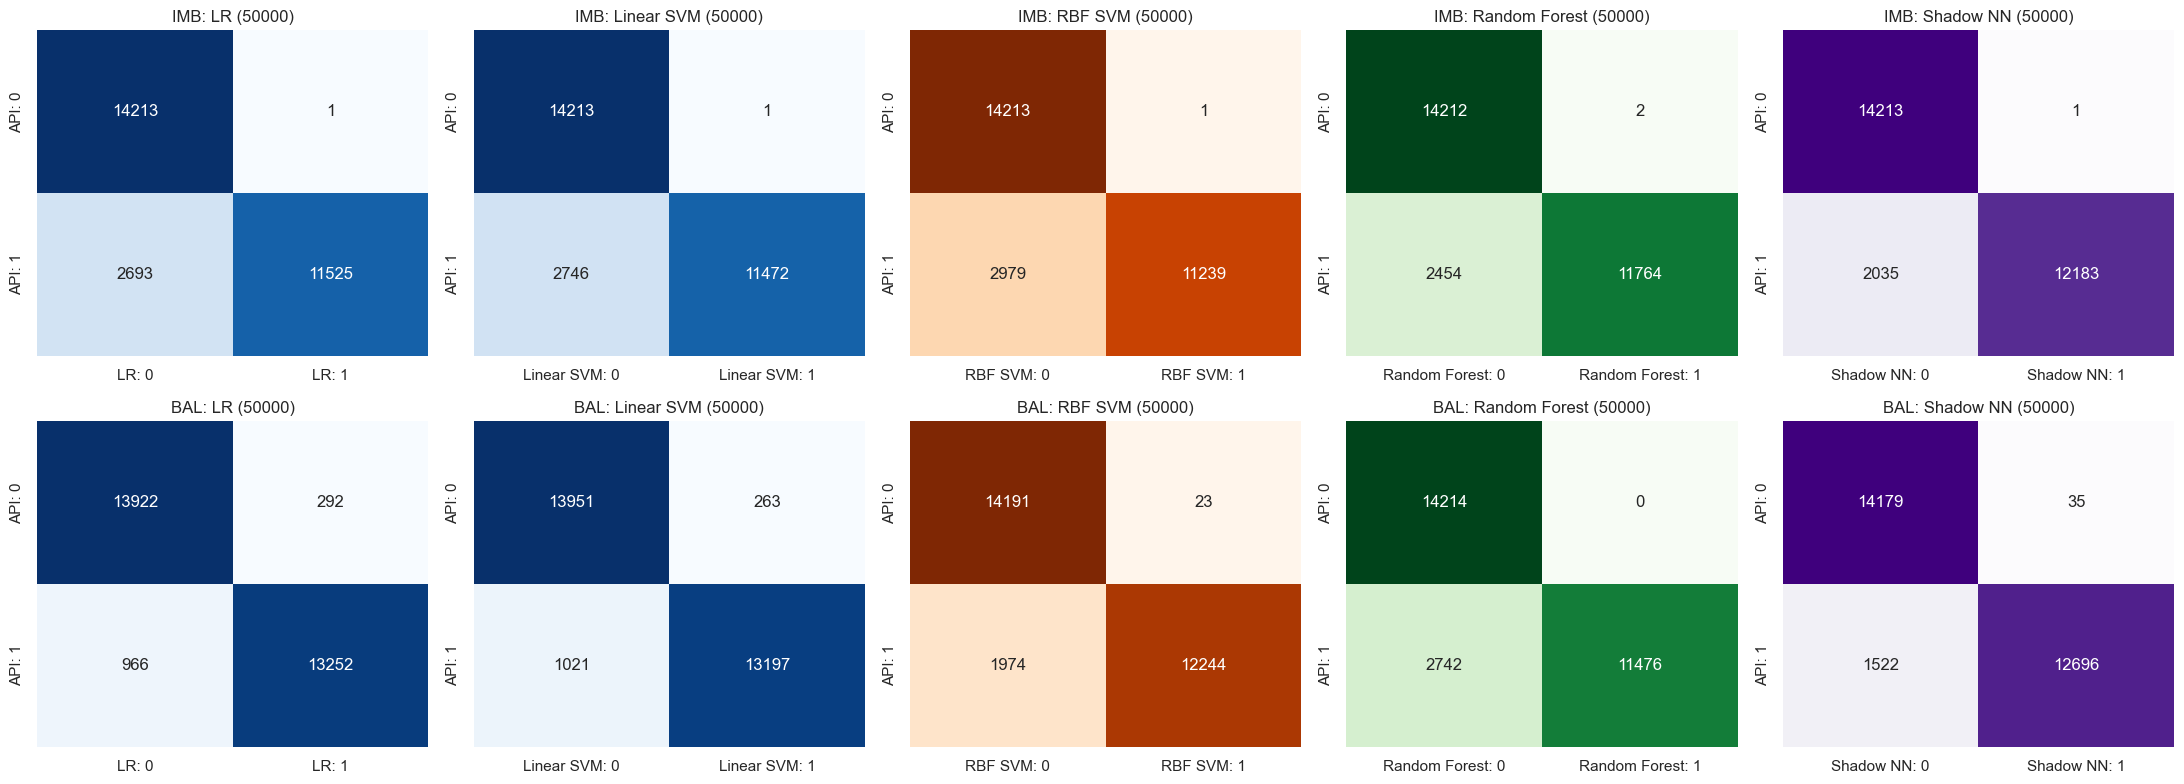

In [50]:
print(f"\nVisualizing Unseen Proxy Heatmaps. Best Imbalanced Budget: {best_unseen_imb_budget} | Best Balanced Budget: {best_unseen_bal_budget}\n")

# Setup a 2x5 grid. Top row = Imbalanced, Bottom row = Balanced
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

model_keys = ['lr', 'svm_lin', 'svm_rbf', 'rf', 'nn']
titles = ['LR', 'Linear SVM', 'RBF SVM', 'Random Forest', 'Shadow NN']
cmaps = ['Blues', 'Blues', 'Oranges', 'Greens', 'Purples']

# Plot Row 1: Imbalanced (Unseen)
for col, (key, title, cmap) in enumerate(zip(model_keys, titles, cmaps)):
    cm = confusion_matrix(y_mlp, best_unseen_imb_preds[key])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[0, col], 
                xticklabels=[f'{title}: 0', f'{title}: 1'], yticklabels=['API: 0', 'API: 1'])
    axes[0, col].set_title(f"IMB: {title} ({best_unseen_imb_budget})")

# Plot Row 2: Balanced (Unseen)
for col, (key, title, cmap) in enumerate(zip(model_keys, titles, cmaps)):
    cm = confusion_matrix(y_mlp, best_unseen_bal_preds[key])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[1, col], 
                xticklabels=[f'{title}: 0', f'{title}: 1'], yticklabels=['API: 0', 'API: 1'])
    axes[1, col].set_title(f"BAL: {title} ({best_unseen_bal_budget})")

plt.tight_layout()
plt.show()

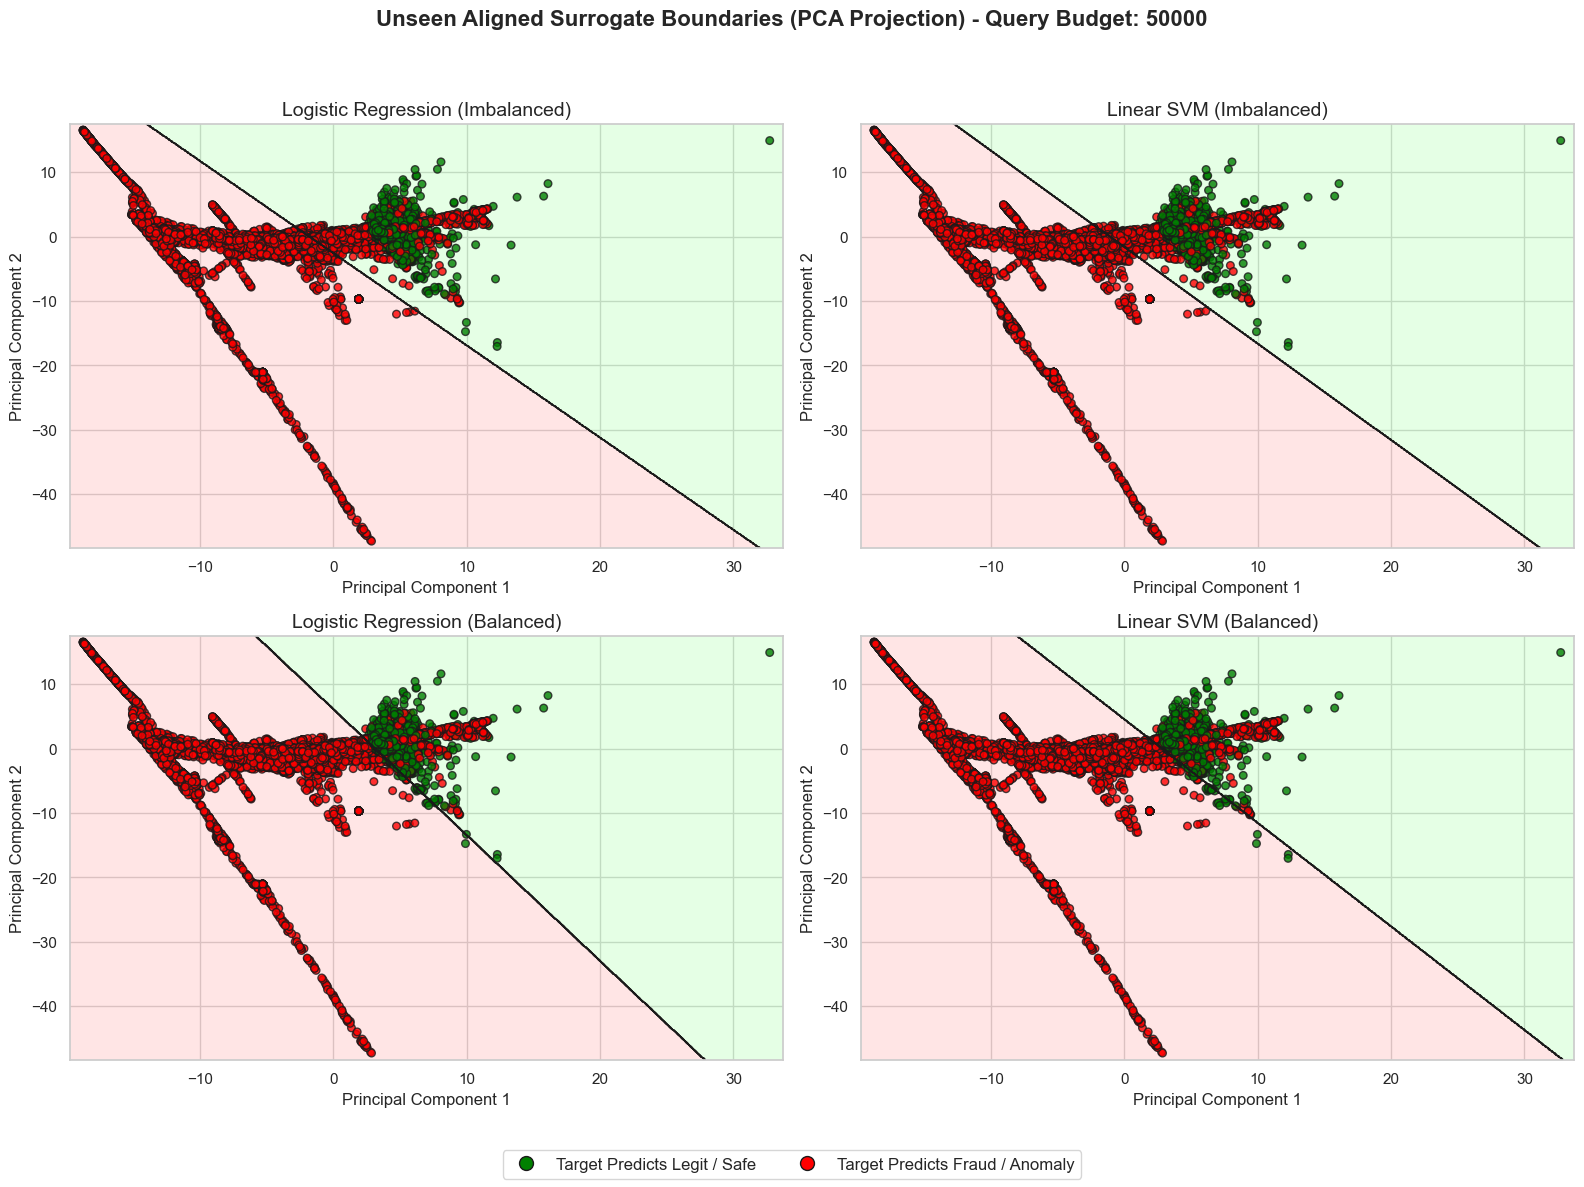

In [51]:
# Visualize Unseen Aligned Proxy Boundaries
budget_to_visualize_unseen = best_unseen_bal_budget

visualize_boundaries_pca(
    X_eval=X_eval_mlp_attacker_unseen_scaled, 
    y_true=y_mlp, 
    lr_imb=mlp_surrogates_lr_unseen_imb, 
    svm_imb=mlp_surrogates_svm_unseen_imb, 
    lr_bal=mlp_surrogates_lr_unseen_bal, 
    svm_bal=mlp_surrogates_svm_unseen_bal, 
    budget=budget_to_visualize_unseen,
    title="Unseen Aligned Surrogate Boundaries (PCA Projection)"
)

## Partial Data Leakage Credit Card Fraud Detection Dataset 2023 Trained Models Results

In [52]:
stolen_budgets = [100, 500, 1000, 2000, 5000, 10000, 20000]

mlp_surrogates_lr_stolen, mlp_surrogates_svm_stolen, mlp_surrogates_svm_rbf_stolen, mlp_surrogates_rf_stolen, mlp_surrogates_nn_stolen = {}, {}, {}, {}, {}

for b in stolen_budgets:
    mlp_surrogates_lr_stolen[b] = joblib.load(f"surrogate_proxy_mlp_lr_leak_dataset_{b}.pkl")
    mlp_surrogates_svm_stolen[b] = joblib.load(f"surrogate_proxy_mlp_svm_leak_dataset_{b}.pkl")
    mlp_surrogates_svm_rbf_stolen[b] = joblib.load(f"surrogate_proxy_mlp_svm_rbf_leak_dataset_{b}.pkl") 
    mlp_surrogates_rf_stolen[b] = joblib.load(f"surrogate_proxy_mlp_rf_leak_dataset_{b}.pkl")
    mlp_surrogates_nn_stolen[b] = joblib.load(f"surrogate_proxy_mlp_nn_leak_dataset_{b}.pkl")

print("--- Surrogate Model Fidelity (Leaked Target Data) ---")
print(f"{'Budget':<8} | {'LR':<7} | {'Lin SVM':<7} | {'RBF SVM':<7} | {'RF':<7} | {'Shadow NN':<7}")
print("-" * 65)

best_mlp_budget_stolen = stolen_budgets[0]
best_overall_fidelity_stolen = 0
best_predictions_stolen = {}
accuracy_table_rows_stolen = []

for b in stolen_budgets:
    # Generate Predictions using the Leaked Data Scaler
    y_surr_lr = mlp_surrogates_lr_stolen[b].predict(X_eval_mlp_attacker_leak_scaled)
    y_surr_svm = mlp_surrogates_svm_stolen[b].predict(X_eval_mlp_attacker_leak_scaled)
    y_surr_svm_rbf = mlp_surrogates_svm_rbf_stolen[b].predict(X_eval_mlp_attacker_leak_scaled)
    y_surr_rf = mlp_surrogates_rf_stolen[b].predict(X_eval_mlp_attacker_leak_scaled)
    y_surr_nn = mlp_surrogates_nn_stolen[b].predict(X_eval_mlp_attacker_leak_scaled)
    
    # Fidelity computation (Against Target API)
    fid_lr = accuracy_score(y_mlp, y_surr_lr)
    fid_svm = accuracy_score(y_mlp, y_surr_svm)
    fid_svm_rbf = accuracy_score(y_mlp, y_surr_svm_rbf)
    fid_rf = accuracy_score(y_mlp, y_surr_rf)
    fid_nn = accuracy_score(y_mlp, y_surr_nn)
    
    print(f"{b:<8} | {fid_lr*100:>6.2f}% | {fid_svm*100:>6.2f}% | {fid_svm_rbf*100:>6.2f}% | {fid_rf*100:>6.2f}% | {fid_nn*100:>6.2f}%")
    
    # Ground Truth computation (Against True Labels)
    acc_lr = accuracy_score(y_ground_truth, y_surr_lr)
    acc_svm = accuracy_score(y_ground_truth, y_surr_svm)
    acc_svm_rbf = accuracy_score(y_ground_truth, y_surr_svm_rbf)
    acc_rf = accuracy_score(y_ground_truth, y_surr_rf)
    acc_nn = accuracy_score(y_ground_truth, y_surr_nn)
    
    accuracy_table_rows_stolen.append(f"{b:<8} | {acc_lr*100:>6.2f}% | {acc_svm*100:>6.2f}% | {acc_svm_rbf*100:>6.2f}% | {acc_rf*100:>6.2f}% | {acc_nn*100:>6.2f}%")
    
    if fid_nn > best_overall_fidelity_stolen:
        best_overall_fidelity_stolen = fid_nn
        best_mlp_budget_stolen = b
        # Capture best predictions to plot the heatmap
        best_predictions_stolen = {
            'lr': y_surr_lr,
            'svm_lin': y_surr_svm,
            'svm_rbf': y_surr_svm_rbf,
            'rf': y_surr_rf,
            'nn': y_surr_nn
        }

print("\n--- Surrogate Model Ground Truth Accuracy (Leaked Data) ---")
print(f"{'Budget':<8} | {'LR':<7} | {'Lin SVM':<7} | {'RBF SVM':<7} | {'RF':<7} | {'Shadow NN':<7}")
print("-" * 65)
for row in accuracy_table_rows_stolen:
    print(row)

--- Surrogate Model Fidelity (Leaked Target Data) ---
Budget   | LR      | Lin SVM | RBF SVM | RF      | Shadow NN
-----------------------------------------------------------------
100      |  92.94% |  91.28% |  91.08% |  93.01% |  92.70%
500      |  94.88% |  95.05% |  94.86% |  95.24% |  94.98%
1000     |  95.41% |  95.56% |  95.49% |  96.08% |  96.53%
2000     |  96.31% |  96.39% |  96.09% |  97.21% |  98.04%
5000     |  96.35% |  96.29% |  97.13% |  98.17% |  98.97%
10000    |  96.35% |  96.14% |  97.97% |  98.80% |  99.40%
20000    |  96.43% |  96.21% |  98.47% |  99.43% |  99.69%

--- Surrogate Model Ground Truth Accuracy (Leaked Data) ---
Budget   | LR      | Lin SVM | RBF SVM | RF      | Shadow NN
-----------------------------------------------------------------
100      |  92.94% |  91.28% |  91.07% |  93.01% |  92.70%
500      |  94.86% |  95.03% |  94.84% |  95.23% |  94.96%
1000     |  95.40% |  95.54% |  95.48% |  96.07% |  96.51%
2000     |  96.29% |  96.36% |  96.07% | 


Visualizing Stolen Data Heatmaps. Best Overall Budget: 20000



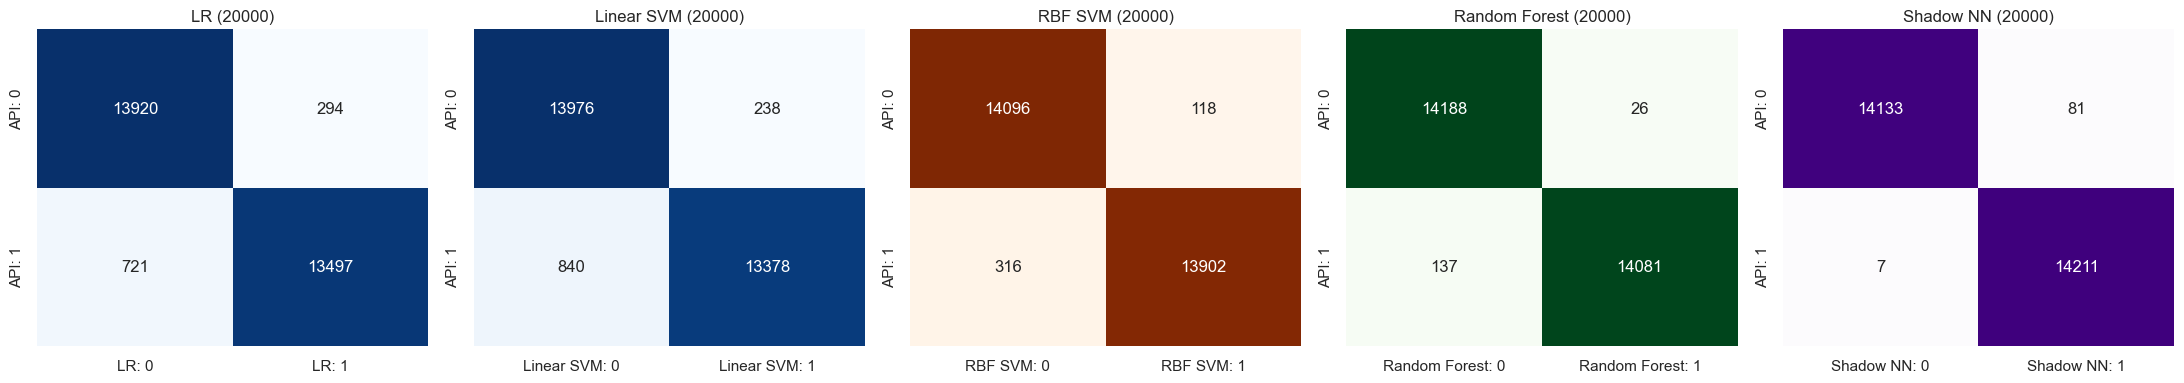

In [53]:
print(f"\nVisualizing Stolen Data Heatmaps. Best Overall Budget: {best_mlp_budget_stolen}\n")

# Setup a 1x5 grid since there is no Imbalanced/Balanced distinction here
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

model_keys = ['lr', 'svm_lin', 'svm_rbf', 'rf', 'nn']
titles = ['LR', 'Linear SVM', 'RBF SVM', 'Random Forest', 'Shadow NN']
cmaps = ['Blues', 'Blues', 'Oranges', 'Greens', 'Purples']

for col, (key, title, cmap) in enumerate(zip(model_keys, titles, cmaps)):
    cm = confusion_matrix(y_mlp, best_predictions_stolen[key])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[col], 
                xticklabels=[f'{title}: 0', f'{title}: 1'], yticklabels=['API: 0', 'API: 1'])
    axes[col].set_title(f"{title} ({best_mlp_budget_stolen})")

plt.tight_layout()
plt.show()

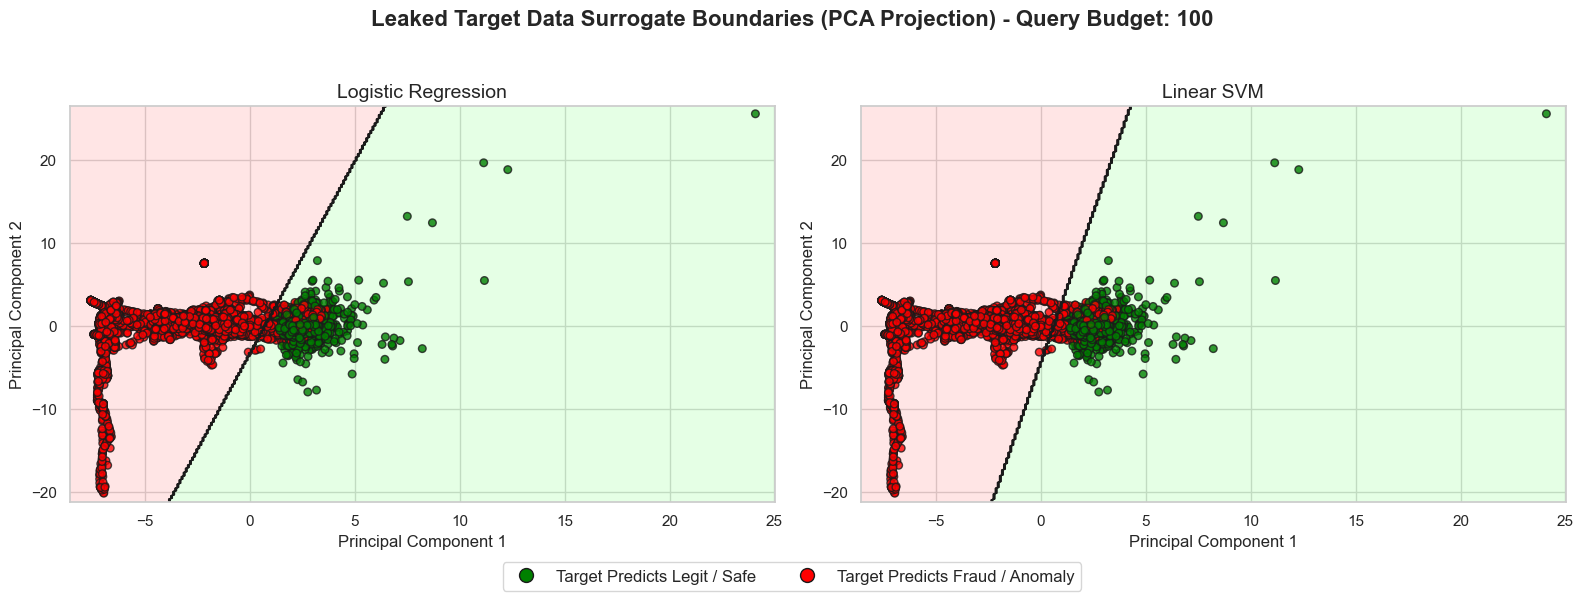

In [54]:
def visualize_stolen_boundaries_pca(X_eval, y_true, lr_stolen, svm_stolen, budget, title="Surrogate Decision Boundaries (PCA Projection)"):
    # Dim reduction to 2D 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_eval)

    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    
    step_size = 0.1 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),
                         np.arange(y_min, y_max, step_size))
    
    mesh_2d = np.c_[xx.ravel(), yy.ravel()]
    mesh_high_d = pca.inverse_transform(mesh_2d)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"{title} - Query Budget: {budget}", fontsize=16, fontweight='bold')

    # Light Green (Safe), Light Red (Fraud)
    cmap_light = ListedColormap(['#AAFFAA', '#FFAAAA'])
    
    # Scatter Points: Solid Green (Safe/0), Solid Red (Fraud/1)
    cmap_bold = ListedColormap(['#008000', '#FF0000']) 

    models_to_plot = [
        (lr_stolen[budget], "Logistic Regression", axes[0]),
        (svm_stolen[budget], "Linear SVM", axes[1]),
    ]

    for model, ax_title, ax in models_to_plot:
        Z = model.predict(mesh_high_d)
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
        ax.contour(xx, yy, Z, colors='k', linewidths=0.8) 
        ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap=cmap_bold, edgecolor='k', s=30, alpha=0.8)

        ax.set_title(ax_title, fontsize=14)
        ax.set_xlabel("Principal Component 1")
        ax.set_ylabel("Principal Component 2")

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#008000', markersize=10, markeredgecolor='k'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF0000', markersize=10, markeredgecolor='k')
    ]
    fig.legend(handles, ['Target Predicts Legit / Safe', 'Target Predicts Fraud / Anomaly'], loc='lower center', ncol=2, fontsize=12)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
    plt.show()

budget_to_visualize = 100

visualize_stolen_boundaries_pca(
    X_eval=X_eval_mlp_attacker_leak_scaled, 
    y_true=y_mlp, 
    lr_stolen=mlp_surrogates_lr_stolen, 
    svm_stolen=mlp_surrogates_svm_stolen, 
    budget=budget_to_visualize,
    title="Leaked Target Data Surrogate Boundaries (PCA Projection)"
)

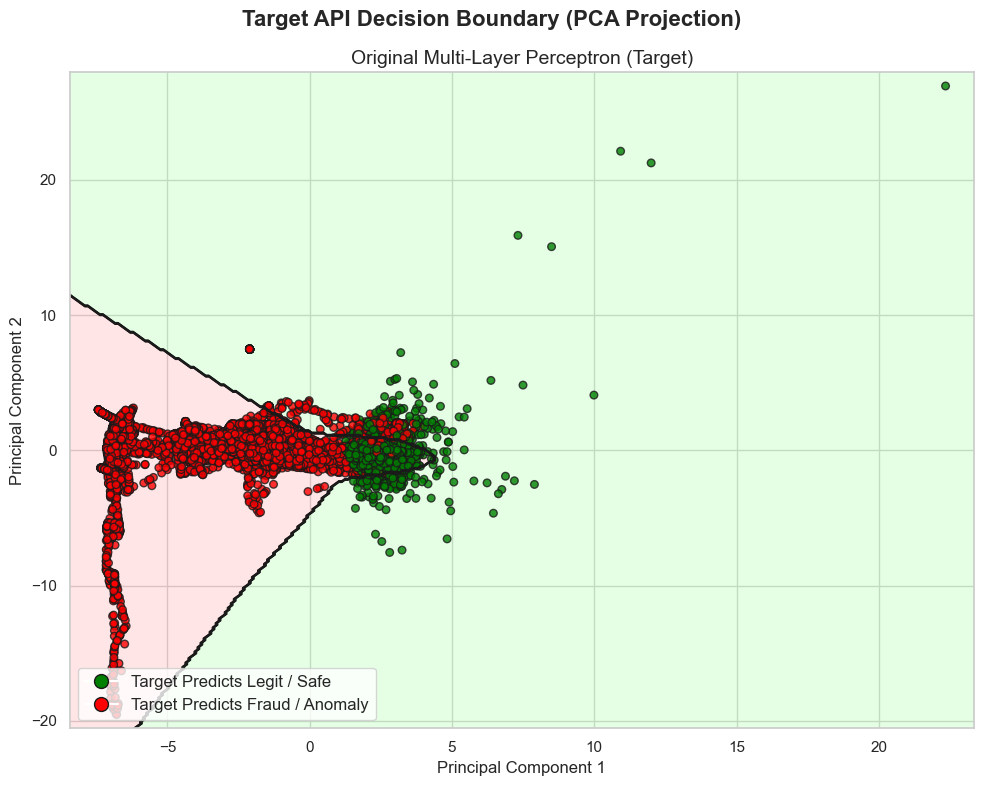

In [55]:
def visualize_original_mlp_pca(X_eval_raw, y_true, target_model, title="Target API Decision Boundary (PCA Projection)", resolution=300):
    scaler = target_model.named_steps['standardscaler']
    X_eval_scaled = scaler.transform(X_eval_raw)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_eval_scaled)
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    mesh_2d = np.c_[xx.ravel(), yy.ravel()]
    mesh_high_d_scaled = pca.inverse_transform(mesh_2d)
    mesh_high_d_raw = scaler.inverse_transform(mesh_high_d_scaled)
    mesh_df = pd.DataFrame(mesh_high_d_raw, columns=X_eval_raw.columns)

    Z = target_model.predict(mesh_df)
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    cmap_light = ListedColormap(['#AAFFAA', '#FFAAAA'])
    cmap_bold = ListedColormap(['#008000', '#FF0000']) 

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.8) 
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap=cmap_bold, edgecolor='k', s=30, alpha=0.8)

    ax.set_title("Original Multi-Layer Perceptron (Target)", fontsize=14)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#008000', markersize=10, markeredgecolor='k'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF0000', markersize=10, markeredgecolor='k')
    ]
    ax.legend(handles, ['Target Predicts Legit / Safe', 'Target Predicts Fraud / Anomaly'], loc='lower left', fontsize=12)

    plt.tight_layout() 
    plt.show()

visualize_original_mlp_pca(
    X_eval_raw=X_eval_mlp_raw, 
    y_true=y_mlp,  
    target_model=mlp_api
)


The evaluation of the mathematically unaligned 2013 Proxy reveals the severe volatility and limitations of black-box extraction under strict information constraints.

In the imbalanced scenario, Logistic Regression unexpectedly outperforms all other models, climbing steadily to an 84.04% fidelity at a 50,000 query budget. In an environment flooded with unaligned semantic noise and extreme imbalance, LR's reliance on log-loss probabilities allows it to gently shift its boundary based on dense clusters. In contrast, hard-margin models like the Linear SVM get rigidly pinned by extreme outliers in the misaligned data, causing them to stagnate near 50-59%.

Conversely, the Shadow Neural Network exhibits its highest fidelity at the lowest budget (67.78% at 1,000 queries), but drops significantly as the budget scales (down to 57.82% at 50,000). At low budgets, the highly parameterized network memorizes isolated pockets of the proxy data, that coincidentally overlap with the target's logic. As the query volume increases, the sheer density of the unaligned semantic noise overwhelms the architecture, causing "catastrophic forgetting" of those initial useful boundaries and dragging the fidelity down toward random guessing.

A critical phenomenon observed across both linear models is that scaling the query budget eventually degrades extraction fidelity. For example, the Balanced Logistic Regression peaks at an impressive 89.72% at 50,000 queries but drops back to 78.51% at 100,000 queries. Similarly, the Balanced Linear SVM spikes to 86.05% at 20,000 queries, plummets to 58.12% at 50,000, and recovers slightly at 100,000. This volatility proves, that in a misaligned proxy space, adding more data eventually introduces more geometric noise. The boundary is violently pulled away from the optimal intersection as out-of-distribution (OOD) artifacts overwhelm the surrogate.

When algorithmic balancing is applied, the results fracture based on architecture capacity. For highly non-linear models (Random Forest, RBF SVM), forcing balance on unaligned noise is detrimental .The models shatter their decision spaces chasing fake geometric targets, resulting in stagnant or degraded fidelity. However, balancing provides a massive boost to the linear models. Weighting the rare minority class acts as an anchor for a global hyperplane. For LR, it pushed fidelity to 89.72%, and for the Linear SVM, it briefly forced a highly accurate hyperplane (86.05%), before noise degraded it again.

As expected, the combination of geometric PCA misalignment and extreme statistical imbalance heavily pushed the False Positive rate. When balancing forced the models to acknowledge the minority class, the surrogates overcompensated, predicting fraud (1) where the API correctly predicted safe (0) because the underlying distributions did not match.

The 2D PCA visualization reveals exactly why the linear models ultimately fail to achieve perfect extraction here. The underlying data distribution creates a sandwiched stratification: a line of red (fraud), a line of green (safe) and another line of red. Because the surrogates are limited to drawing a single straight line, their decision boundary inevitably cuts straight through a dense red cluster, guaranteeing massive misclassification regions.

By transitioning to the Unseen 2023 Proxy, the extraction operates under the exact same extreme class imbalance (0.35% fraud), but the geometric PCA semantic drift is completely eliminated.

The results are overwhelmingly more positive, achieving higher fidelities at significantly lower query budgets. Because the proxy dataset is geometrically aligned with the victim model's training data, every query maps perfectly to the victim's underlying manifold, drastically increasing sample efficiency [6].

In the imbalanced setting, the heatmaps reveal that without intervention, the True Positives completely disappear at lower budgets .The models simply predict '0' to achieve baseline accuracy. However, when algorithmic balancing is introduced, it works flawlessly. Unlike Phase 1 where balancing amplified noise, balancing in an aligned feature space amplifies true geometric signal. The Logistic Regression surrogate stabilizes and peaks at an exceptional 95.58% fidelity.

The 2D visualization highlights the structural clarity of the aligned dataset. Instead of scattered bands, the data projects as a dense, localized "ball" of legitimate transactions intercepted by a distinct "tilted T" formation of fraudulent transactions. The aligned surrogates successfully draw precise boundaries that cleanly slice the "tilted T" away from the central legitimate cluster.

The final phase simulates a severe threat model where the attacker gains access to a leaked, perfectly balanced slice of the target's original training data.

In the previous phases, the Shadow Neural Network struggled to exceed linear models despite sharing the exact architecture of the victim API. Deep networks require dense, high-quality data to converge and are prone to overfitting in noisy proxy settings. However, when provided with perfectly balanced and geometrically pristine data, the Shadow NN overtook all other architectures, leveraging its full non-linear capacity to perfectly map the victim's complex logic [3].

The extraction was wildly successful with virtually no query overhead. At a mere 100 queries, all models surpassed 91% fidelity. Zero geometric noise and zero class imbalance mean that every single query provides maximum possible information gain [1]. Given a budget of just 20,000 queries, the Shadow NN achieved an astonishing 99.69% fidelity. The 2D PCA decision boundary perfectly reflects this: the linear surrogates draw flawless, stark hyperplanes that surgically bisect the target API's logic clusters, enclosing the target's predictions with near-perfect precision and leaving almost no scattered points misclassified.

Evaluating the likelihood of these three attacks in real-world MLaaS environments provides critical context for defense strategies:

1. **The Unaligned Public Proxy (Phase 1 - High Likelihood):** This is the most highly probable attack vector in the wild. Attackers frequently leverage easily accessible, domain-adjacent public datasets to query proprietary APIs [4]. While fidelity is structurally limited by domain drift and volatile scaling, it is practically free to execute and requires zero internal system access.
2. **The Unseen Aligned Proxy (Phase 2 - Moderate Likelihood):** This represents a moderate likelihood scenario. It occurs when an adversary gains access to the same operational domain space as the victim, such as a competing financial institution utilizing its own unannotated transaction logs to successfully steal a market leader's fraud detection logic [6].
3. **The Leaked Target Data (Phase 3 - Low Likelihood, Critical Impact):** This is the least likely to occur, as it requires a direct breach of the victim's proprietary data pipelines or an insider threat. However, it represents the absolute worst-case scenario, demonstrating that if an attacker acquires even a trivial fraction of the training data (e.g., 100 rows), the total, high-fidelity theft of the model's intellectual property is virtually guaranteed.

# Evasion Attack

In [56]:
import numpy as np
import pandas as pd
import joblib

# Logistic Regression surrogate model, target API and attacker preprocessing pipeline
lr_surrogate = joblib.load(f"surrogate_proxy_mlp_lr_unseen_dataset_{20000}_balanced.pkl") # Select one of the models, but ensure afterwards that the correct scaler is used
mlp_api = joblib.load("nn_model.pkl")
attacker_scaler = joblib.load("attacker_scaler_unseen.pkl") # Three types of scalers

features = [f"V{i}" for i in range(1, 29)] + ["Amount"]

# Evaluation data and select a known fraudulent transaction
eval_df = pd.read_csv("creditcard_2023_eval.csv")
fraud_sample = eval_df[eval_df["Class"] == 1].iloc[0]

x_original = pd.DataFrame([fraud_sample[features]])

baseline_pred = mlp_api.predict(x_original)[0]
baseline_prob = mlp_api.predict_proba(x_original)[0][1]

print("Original transaction evaluation")
print("--------------------------------")
print(f"Amount: ${fraud_sample['Amount']:.2f}")
print(f"Prediction: {'Fraud' if baseline_pred == 1 else 'Safe'}")
print(f"Fraud confidence: {baseline_prob * 100:.2f}%\n")

# Logistic Regression surrogate analysis
weights = lr_surrogate.coef_[0]

# Selecting the two strongest negative LR weights
important_idx = np.argsort(weights)[:2]

feature_1 = features[important_idx[0]]
feature_2 = features[important_idx[1]]

print("Surrogate-guided feature selection")
print(f"Selected features: {feature_1}, {feature_2}")

# Adversarial Example
x_adversarial = x_original.copy()

x_adversarial[feature_1] += 5.0
x_adversarial[feature_2] += 5.0

# Scale input for LR surrogate
x_adv_scaled = pd.DataFrame(
    attacker_scaler.transform(x_adversarial),
    columns=features
)

# Surrogate prediction
lr_pred = lr_surrogate.predict(x_adv_scaled)[0]

# Target API prediction
pred = mlp_api.predict(x_adversarial)[0]
prob = mlp_api.predict_proba(x_adversarial)[0][1]

print("Adversarial evaluation")
print("----------------------")
print(f"LR surrogate prediction: {'Fraud' if lr_pred == 1 else 'Safe'}")
print(f"Target API prediction: {'Fraud' if pred == 1 else 'Safe'}")

if pred == 0:
    print("The perturbation successfully bypassed the target model.")
else:
    print("The target model still classified the transaction as fraud.")

Original transaction evaluation
--------------------------------
Amount: $5278.36
Prediction: Fraud
Fraud confidence: 100.00%

Surrogate-guided feature selection
Selected features: V10, V16
Adversarial evaluation
----------------------
LR surrogate prediction: Safe
Target API prediction: Safe
The perturbation successfully bypassed the target model.


The process begins by using a Logistic Regression surrogate model to approximate the decision boundary of the target MLP fraud detection API. 

From the surrogate model, the coefficient vector is extracted and interpreted as a linear approximation of feature influence in the transformed feature space. By sorting these weights, the two features with the most strongly negative contribution to the fraud class are identified, meaning they most strongly push the decision toward a non-fraud outcome when increased. These features are then selected as the primary leverage points for constructing an adversarial example.

The attack itself is performed by applying a uniform perturbation to the selected surrogate-identified features. However, it is important to interpret this carefully: the variables V1–V28 are PCA-transformed and anonymized, so they do not correspond to real-world transaction properties such as merchant type or location. As a result, the modifications do not represent actionable fraud behavior changes but instead represent shifts in an abstract latent feature space. The only partially interpretable feature, Amount, is also included in the model, but its low influence in the surrogate (Z-score: -0.12) indicates that it contributes minimally to the decision boundary compared to the latent components.

The perturbed input is then passed through both the surrogate and the target MLP API. If the surrogate predicts a shift toward non-fraud, this indicates local agreement between the approximated and true decision boundaries and the target model may also change its prediction due to transferability. In this case, the attack demonstrates that gradients or linear approximations captured by the surrogate can successfully identify sensitive regions in the target model’s feature space, even without direct access to its parameters.

However, this success should be interpreted as a theoretical demonstration of adversarial transferability rather than a realistic fraud manipulation strategy. The attack exploits structure in a high-dimensional latent representation rather than manipulable transaction attributes, meaning it functions as a feature-space evasion attack. In practical fraud systems, attackers are constrained to modifying observable variables, and the PCA-transformed features obscure any direct mapping to such real-world interventions.